<a href="https://colab.research.google.com/github/bttglc/plastic-attractor-notebook/blob/main/Attractor%2BCuedAttractorModelcontroltestoutput.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Running baseline...
Baseline progress: 25%
Baseline progress: 50%
Baseline progress: 75%
Baseline progress: 100%
Running Control 1 (shuffled cues)...
Control 1 progress: 25%
Control 1 progress: 50%
Control 1 progress: 75%
Control 1 progress: 100%
Running Control 2 (novel cue generalization)...
Control 2 progress: 25%
Control 2 progress: 50%
Control 2 progress: 75%
Control 2 progress: 100%
Running Control 3 (omitted combo)...
Control 3 progress: 25%
Control 3 progress: 50%
Control 3 progress: 75%
Control 3 progress: 100%
All simulations complete.



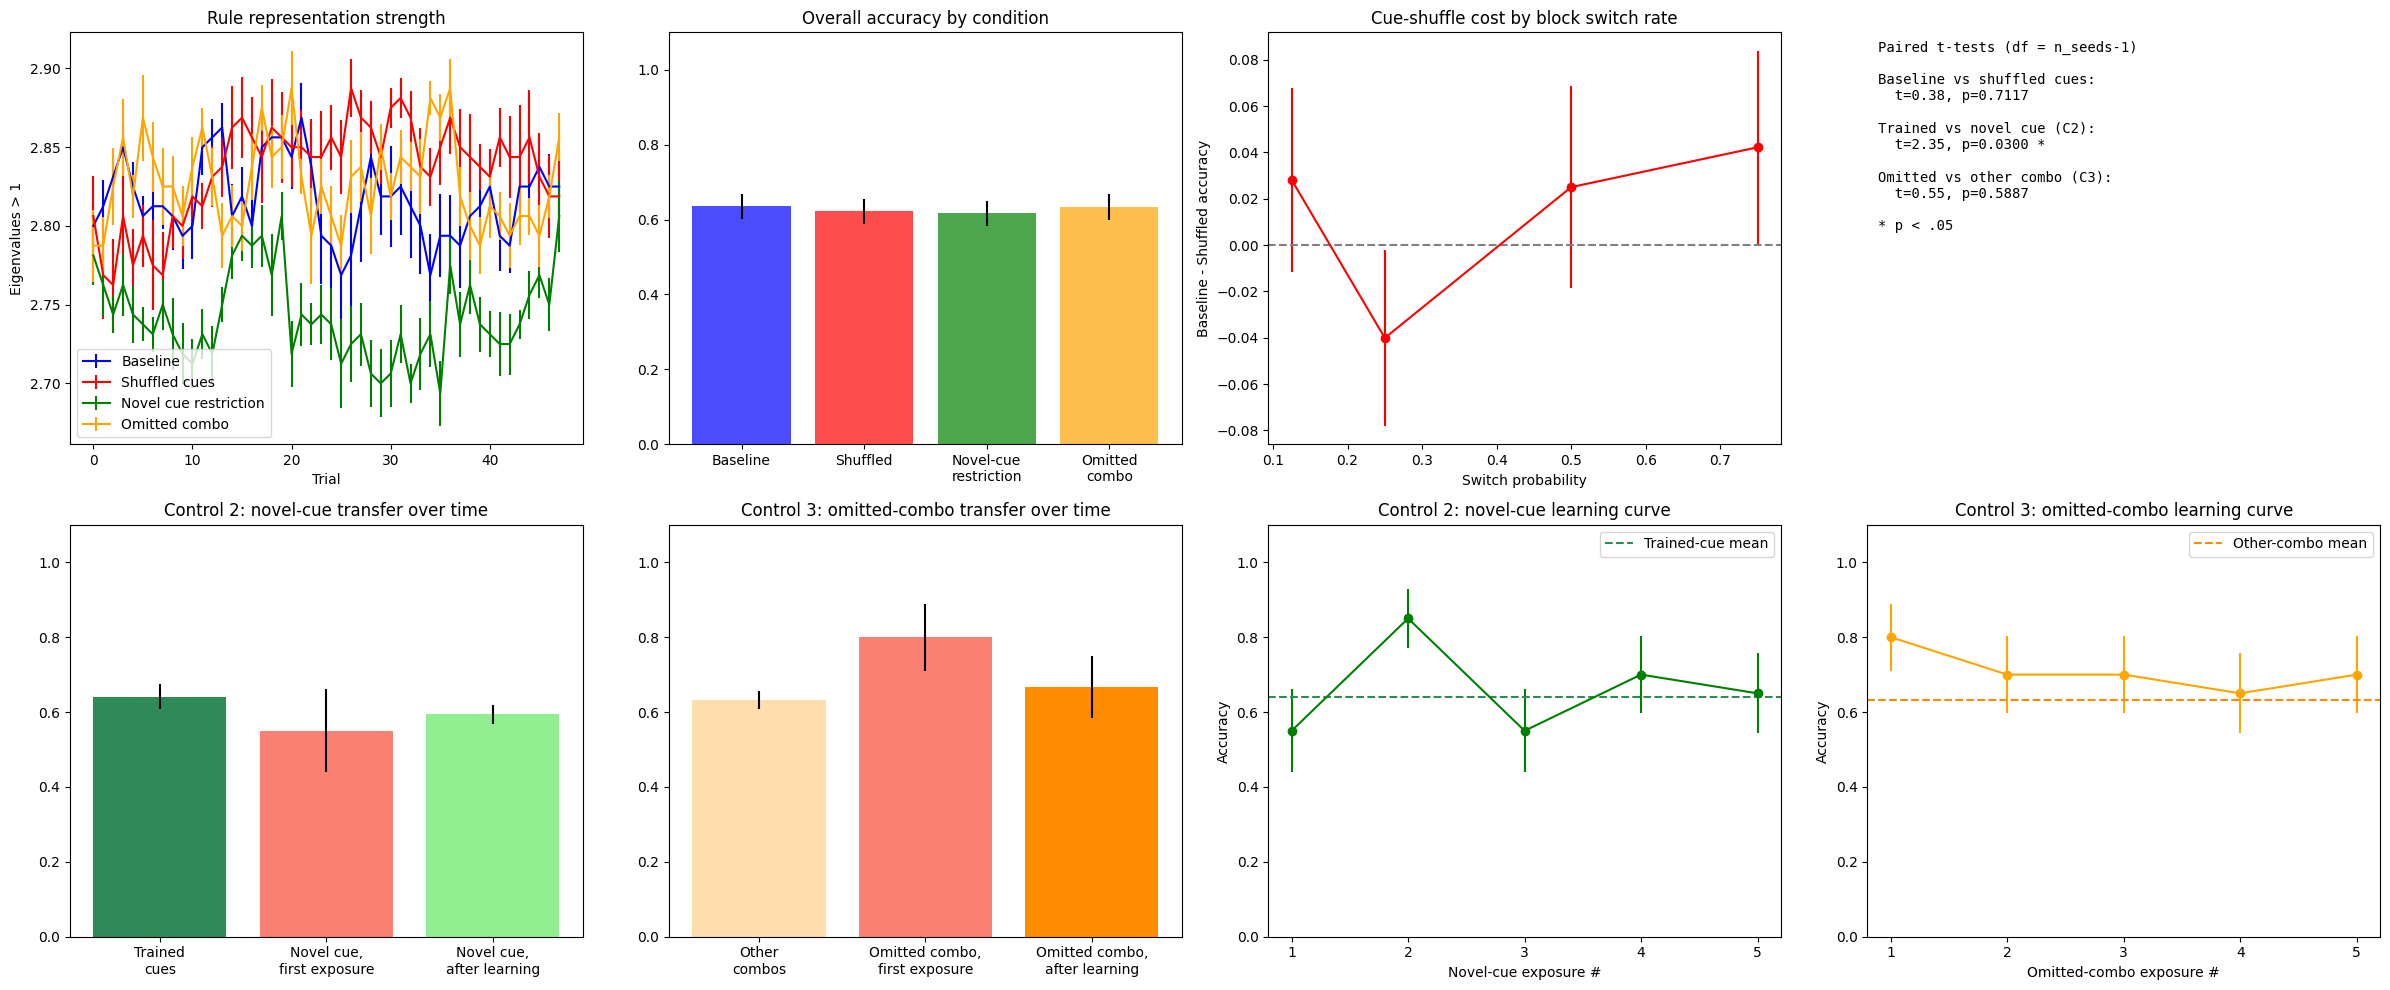


=== SUMMARY ===
Baseline accuracy:              0.635
Shuffled-cue accuracy:          0.622
Novel-cue-restriction accuracy: 0.617
Omitted-combo accuracy:         0.634
  -> paired t-test baseline vs shuffled: t=0.375, p=0.71168

Control 2 - trained cues:                  0.641
Control 2 - novel cue, FIRST exposure:     0.550
Control 2 - novel cue, after learning:      0.594
Control 2 - novel cue, ALL exposures:      0.594
  -> paired t-test trained vs novel:        t=2.345, p=0.03002
  -> mean trial of first A2 exposure:       6.4 / 384 test trials
  -> mean trial of first B2 exposure:       4.5 / 384 test trials
  -> accuracy by novel-cue exposure # (1-5): [0.55, 0.85, 0.55, 0.7, 0.65]

Control 3 - other combos:                  0.632
Control 3 - omitted combo, FIRST exposure: 0.800
Control 3 - omitted combo, after learning:  0.668
Control 3 - omitted combo, ALL exposures:  0.673
  -> paired t-test omitted vs other:        t=0.550, p=0.58872
  -> mean trial of first omitted exposure:

In [5]:
"""
Note: The core Plastic Attractor Model was provided by the original project and modifications made by Rene

This script adds three control analyses alongside summary statistics to investigate whether the model generalises abstract
rules beyond memorising specific cues and pairings


Three Controls:
  1. In the first control, Cue identities are randomly reassigned during testing while stimuli remain unchanged. If performance remains similar to baseline, this suggests the model is not heavily dependent on the original cue identities.
  2. In the second control, only one cue per rule is taught during practice (A1,B1), then during testsing, novel cues are added in (A2,B2). This is to check if the model can generalise the abstarct rule to novel cues.
  3. In the third control, we removed one cue-stimulus pair during practice. If model still performs correctly when combination first appears, it might suggest generalisation rather than memorisation.
"""

#Importing packages
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

#Additional optional arguments have been implemented to act as experimental controls to the Plastic Attractor Model
def plasticattractor_sim(num_trials, rnd_seed, switch_probs, practice_trials,
                         TMS_sim, TMS_start,alpha_cc_inhib=-.45, alpha_cc_decay=1,
                         alpha_cf_gain=.08,alpha_ff_inhib=-.28, alpha_ff_decay=.73, alpha_fc_gain=.04,beta=.175,
                         lr_short=.02, lr_long=.0002,w_short_bound=1, w_long_bound=.2,w_short_weight=1, w_long_weight=1,
                         shuffle_cues_test=False,practice_cue_restriction=None,omit_practice_combo=None):
    np.random.seed(rnd_seed)
    num_features = 10
    num_conjunction = 4
    alpha = np.array([alpha_cc_inhib, alpha_cc_decay, alpha_cf_gain,alpha_ff_inhib, alpha_ff_decay, alpha_fc_gain])
    gamma = lr_short
    action_idx = slice(8, num_features)

    feature_groups = [[0, 1], [2, 3], [4, 5, 6, 7], [8, 9]]
    inhibition_mask = np.zeros([num_features, num_features])
    for group in feature_groups:
        inhibition_mask[np.ix_(group, group)] = 1

    W_ff = alpha[4] * np.eye(num_features) + alpha[3] * inhibition_mask
    W_cc = alpha[1] * np.eye(num_conjunction) + alpha[0] * np.ones(num_conjunction)

    cues = np.zeros([4, num_features])
    cues[0, 4] = 1   # cueA1
    cues[1, 5] = 1   # cueA2
    cues[2, 6] = 1   # cueB1
    cues[3, 7] = 1   # cueB2
    cue_rule = np.array([0, 0, 1, 1]) #This allows us to ask whether the network learns the rule itself or if it just memorises individual cue identities

    stimuli = np.zeros([4, num_features])
    stimuli[0, :4] = [1, 0, 1, 0]   # green square
    stimuli[1, :4] = [1, 0, 0, 1]   # green circle
    stimuli[2, :4] = [0, 1, 1, 0]   # blue square
    stimuli[3, :4] = [0, 1, 0, 1]   # blue circle

    action_teach = np.array([[1, -1], [-1, 1]])
    num_practice_blocks = 2
    num_blocks = num_practice_blocks + len(switch_probs)
    stim_period = 400
    isi = np.full(num_features, -1)
    resp_period = np.zeros(num_features)

    def practice_sequence(rule_idx): #Constructs the practice blocks
        cue_pool = np.where(cue_rule == rule_idx)[0]
        if practice_cue_restriction == 'A1_B1':
            if rule_idx == 0: cue_pool = [0]  # Only A1
            if rule_idx == 1: cue_pool = [2]  # Only B1

        combos = np.array([[cue, stim] for cue in cue_pool for stim in range(4)])

        if omit_practice_combo is not None:
            mask = ~((combos[:, 0] == omit_practice_combo[0]) &(combos[:, 1] == omit_practice_combo[1])) #Removes one combination from practice if running control 3
            combos = combos[mask]

        # Re-tile to match practice_trials approximately
        repeats = int(np.ceil(practice_trials / len(combos)))
        combos = np.tile(combos, (repeats, 1))[:practice_trials]
        np.random.shuffle(combos)
        return np.full(practice_trials, rule_idx), combos[:, 0], combos[:, 1]

    def real_sequence(switch_prob): #Generates a block with trial wise task switching
        rule_seq = np.zeros(num_trials, dtype=int)
        cue_seq = np.zeros(num_trials, dtype=int) #Selects one of the valid cues for the current rule
        rule_seq[0] = np.random.randint(2)
        for trl in range(1, num_trials):
            rule_seq[trl] = 1 - rule_seq[trl - 1] if np.random.rand() < switch_prob else rule_seq[trl - 1]

        for trl in range(num_trials):
            cue_seq[trl] = np.random.choice(np.where(cue_rule == rule_seq[trl])[0])

        if shuffle_cues_test:  #Control 1: it randomly permutes cue across all trials. Stimuli is the same so cue no longer predicts current rule
            np.random.shuffle(cue_seq)

        stim_seq = np.tile([0, 1, 2, 3], num_trials // 4)
        np.random.shuffle(stim_seq)
        return rule_seq, cue_seq, stim_seq

    def stim_generator(rule_seq, cue_seq, stim_seq, practice):
        stimulus, ground_truth, c_labels, s_labels, r_labels, cue_labels, trans_labels = {}, {}, {}, {}, {}, {}, {}
        for trl in range(len(rule_seq)):
            r_idx, c_idx, s_idx = rule_seq[trl], cue_seq[trl], stim_seq[trl]
            correct = (0 if s_idx < 2 else 1) if r_idx == 0 else (0 if s_idx % 2 == 0 else 1)

            stim_input = np.zeros([num_features, stim_period])
            for t in range(stim_period):
                if t <= 50:stim_input[:, t] = isi
                elif 50 <= t <= 100:stim_input[:, t] = stimuli[s_idx, :] + cues[c_idx, :]
                elif 100 <= t <= 350:stim_input[:, t] = resp_period
                elif 350 <= t <= 400: stim_input[:, t] = isi
                if practice and 50 <= t <= 350:stim_input[action_idx, t] = action_teach[correct, :]

            stimulus[trl], ground_truth[trl] = stim_input, correct
            r_labels[trl], cue_labels[trl] = r_idx, c_idx
            trans_labels[trl] = -1 if trl == 0 else ( 2 if rule_seq[trl] != rule_seq[trl - 1] else (1 if cue_seq[trl] != cue_seq[trl - 1] else 0))
            c_labels[trl] = 1 if s_idx < 2 else 2
            s_labels[trl] = 1 if s_idx % 2 == 0 else 2
        return stimulus, ground_truth, c_labels, s_labels, r_labels, cue_labels, trans_labels

    conj_dict, feat_dict, choice_dict, acc_dict, rt_dict, weight_dict = {}, {}, {}, {}, {}, {}
    c_label_dict, s_label_dict, r_label_dict, cue_label_dict, trans_label_dict = {}, {}, {}, {}, {}
    # Kept alongside every block's trials so downstream analysis (novel-cue /omitted-combo splits) doesn't have to guess the stimulus sequence.
    stim_seq_dict = {}
    # Raw rule sequence per block, so downstream analyses can cross novel-cue /omitted-combo effects with switch-vs-repeat trials without decoding it back out of trans_label_dict.
    rule_seq_dict = {}

    w_short, w_long = np.random.rand(num_features, num_conjunction), np.random.rand(num_features, num_conjunction)
    W = w_short_weight * w_short + w_long_weight * w_long

    for blk in range(num_blocks):
        practice = blk < num_practice_blocks
        if practice:rule_seq, cue_seq, stim_seq = practice_sequence(blk)
        else:rule_seq, cue_seq, stim_seq = real_sequence(switch_probs[blk - num_practice_blocks])
        n_trials = len(rule_seq)
        conjunction_units = np.zeros((num_conjunction, stim_period, n_trials))
        feature_units = np.zeros((num_features, stim_period, n_trials))
        choice, rt, accuracy = np.zeros(n_trials), np.zeros(n_trials), np.zeros(n_trials)
        stim_dict, g_truth, c_l, s_l, r_l, cue_l, t_l = stim_generator(rule_seq, cue_seq, stim_seq, practice)

        for trl in range(n_trials):
            stim = stim_dict[trl]
            for t in range(stim_period):
                feature_units[:, t, trl] = np.clip(
                    beta + W_ff @ (feature_units[:, t - 1, trl] - beta)
                    + alpha[2] * W @ (conjunction_units[:, t - 1, trl] - beta)
                    + stim[:, t], 0, 1)
                if TMS_sim and TMS_start <= t <= 100 and TMS_start != 100:
                    conjunction_units[:, t, trl] = 1
                else:
                    conjunction_units[:, t, trl] = np.clip(
                        beta + W_cc @ (conjunction_units[:, t - 1, trl] - beta)
                        + alpha[5] * W.T @ (feature_units[:, t - 1, trl] - beta)
                        + 0.005 * np.random.randn(num_conjunction), 0, 1)
                delta_w = np.outer((feature_units[:, t, trl] - beta), (conjunction_units[:, t, trl] - beta))
                w_short = np.clip(w_short + gamma * delta_w, 0, w_short_bound)
                w_long = np.clip(w_long + lr_long * delta_w, 0, w_long_bound)
                W = w_short_weight * w_short + w_long_weight * w_long

            max_act = np.amax(feature_units[action_idx, 110:, trl])
            act_idx = np.argwhere(feature_units[action_idx, 110:, trl] > 0.98 * max_act)
            choice[trl], rt[trl] = act_idx[0, 0], act_idx[0, 1]
            accuracy[trl] = 1 if choice[trl] == g_truth[trl] else 0
            weight_dict[trl, blk] = W

        conj_dict[blk], feat_dict[blk], choice_dict[blk] = conjunction_units, feature_units, choice
        acc_dict[blk], rt_dict[blk] = accuracy, rt
        c_label_dict[blk], s_label_dict[blk] = c_l, s_l
        r_label_dict[blk], cue_label_dict[blk], trans_label_dict[blk] = r_l, cue_l, t_l
        stim_seq_dict[blk] = np.asarray(stim_seq)
        rule_seq_dict[blk] = np.asarray(rule_seq)
        weight_dict[blk] = W

    return (conj_dict, feat_dict, choice_dict, acc_dict, rt_dict,
            c_label_dict, s_label_dict, r_label_dict, cue_label_dict, trans_label_dict,
            weight_dict, stim_seq_dict, rule_seq_dict)


# End of the Model. The analyses below implement additional experimental controls and evaluation

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
output_dir = os.path.join(base_dir, 'output')
os.makedirs(output_dir, exist_ok=True)

n_seeds = 20 # number of random seeds
num_trials = 48 # trials per real block (must be a multiple of 4)
practice_trials = 48 # trials per practice block (must be a multiple of 8: 2 cues x 4 stimuli)
switch_probs = [0.125, 0.25, 0.5, 0.75] * 2 # probability of a rule switch on each trial, one entry per real block
num_practice_blocks = 2 # blocks 0 and 1 are practice, the rest are real
num_real_blocks = len(switch_probs)
block_kinds = [0.125, 0.25, 0.5, 0.75]
switch_probs_arr = np.array(switch_probs)

model_versions = {'whyte_original': { 'alpha_cc_inhib': -.45, 'alpha_cc_decay': 1, 'alpha_cf_gain': .08, 'alpha_ff_inhib': -.28, 'alpha_ff_decay': .73, 'alpha_fc_gain': .04,
        'beta': .175, 'lr_short': .02, 'lr_long': .0002,'w_short_bound': 1, 'w_long_bound': .2, 'w_short_weight': 1, 'w_long_weight': 1, },}
active_version = 'whyte_original'
omit_combo = (0, 0)  # cue A1 (0) + stimulus 0 (green square)




def run_sims(label, **kwargs):
    results = {}
    for rnd in range(n_seeds):
      results[rnd] = plasticattractor_sim(
            num_trials=num_trials, rnd_seed=rnd, switch_probs=switch_probs,
            practice_trials=practice_trials, TMS_sim=False, TMS_start=None,
            **model_versions[active_version], **kwargs)
      if (rnd + 1) % 5 == 0:
            print(f'{label} progress: {((rnd + 1) / n_seeds) * 100:.0f}%')
    return results


if __name__ == '__main__':
    print("Running baseline...")
    results_baseline = run_sims('Baseline', shuffle_cues_test=False,
                                 practice_cue_restriction=None, omit_practice_combo=None)

    print("Running Control 1 (shuffled cues)...")
    results_control1 = run_sims('Control 1', shuffle_cues_test=True,
                                 practice_cue_restriction=None, omit_practice_combo=None)

    print("Running Control 2 (novel cue generalization)...")
    results_control2 = run_sims('Control 2', shuffle_cues_test=False,
                                 practice_cue_restriction='A1_B1', omit_practice_combo=None)

    print("Running Control 3 (omitted combo)...")
    results_control3 = run_sims('Control 3', shuffle_cues_test=False,
                                 practice_cue_restriction=None, omit_practice_combo=omit_combo)

    print("All simulations complete.\n")

    # Extracting the eigenvalues and evaluating overall accuracy
    def extract_eig_and_acc(results):
        sat_vals = np.zeros([n_seeds, num_trials, num_real_blocks])
        all_acc = []
        seed_acc = np.zeros(n_seeds)  # one accuracy value per seed, for paired stats
        for rnd in range(n_seeds):
            res = results[rnd]
            acc_dict, weights = res[3], res[10]
            block_accs = []
            for blk_idx in range(num_real_blocks):
                actual_blk = blk_idx + num_practice_blocks
                block_mean = np.mean(acc_dict[actual_blk])
                all_acc.append(block_mean)
                block_accs.append(block_mean)
                for trl in range(num_trials):
                    W = weights[trl, actual_blk]
                    vals = np.linalg.eigvals(W @ W.T)
                    sat_vals[rnd, trl, blk_idx] = np.sum(np.real(vals) > 1)
            seed_acc[rnd] = np.mean(block_accs)
        mean_sat = np.mean(np.mean(sat_vals, 0), 1)
        ster_sat = np.std(np.mean(sat_vals, 0), 1) / np.sqrt(n_seeds)
        return mean_sat, ster_sat, all_acc, seed_acc

    mean_sat_baseline, ster_sat_baseline, all_acc_baseline, seed_acc_baseline = extract_eig_and_acc(results_baseline)
    mean_sat_c1, ster_sat_c1, all_acc_c1, seed_acc_c1 = extract_eig_and_acc(results_control1)
    mean_sat_c2, ster_sat_c2, all_acc_c2, seed_acc_c2 = extract_eig_and_acc(results_control2)
    mean_sat_c3, ster_sat_c3, all_acc_c3, seed_acc_c3 = extract_eig_and_acc(results_control3)

    #  CONTROL 1: shuffle cost stratified by switch probability
    shuffle_cost_by_kind = np.zeros([n_seeds, len(block_kinds)])
    for rnd in range(n_seeds):
        accB, accS = results_baseline[rnd][3], results_control1[rnd][3]
        for k, kind in enumerate(block_kinds):
            kind_blocks = np.where(switch_probs_arr == kind)[0] + num_practice_blocks
            accB_kind = np.concatenate([accB[b] for b in kind_blocks])
            accS_kind = np.concatenate([accS[b] for b in kind_blocks])
            shuffle_cost_by_kind[rnd, k] = np.mean(accB_kind) - np.mean(accS_kind)
    mean_shuffle_cost = np.mean(shuffle_cost_by_kind, 0)
    ster_shuffle_cost = np.std(shuffle_cost_by_kind, 0) / np.sqrt(n_seeds)

    #  CONTROL 2: trained vs novel cue, exposure-by-exposure
    # The network keeps learning during testing (the Hebbian updates never turn off), so pooling "all later novel-cue trials" together conflates trials
    # right after the novel cue's first appearance with trials where the network has already adapted to it. Track exposure number explicitly instead of
    # just first-vs-later, and record when each novel cue first showed up.
    N_EXPOSURE_BINS = 5

    def first_exposure_analysis_c2(results, n_exposure_bins=N_EXPOSURE_BINS):
        first_exp_acc, later_novel_acc, trained_acc, novel_acc = [], [], [], []
        first_A2_trial, first_B2_trial = [], []
        exposure_curve = [[] for _ in range(n_exposure_bins)]
        for rnd in range(n_seeds):
            res = results[rnd]
            acc_dict, cue_lab_dict = res[3], res[8]
            novel_count = 0
            seen_A2, seen_B2 = False, False
            first_trial, later_trial, trained_trial, novel_trial = [], [], [], []
            exposure_bins = [[] for _ in range(n_exposure_bins)]
            for blk_idx in range(num_real_blocks):
                actual_blk = blk_idx + num_practice_blocks
                acc = acc_dict[actual_blk]
                cues = np.array([cue_lab_dict[actual_blk][trl] for trl in range(len(acc))])
                for trl in range(len(acc)):
                    c = cues[trl]
                    global_trial = blk_idx * num_trials + trl
                    if c in (1, 3):  # novel cues A2, B2 (never taught in practice)
                        novel_trial.append(acc[trl])
                        if novel_count == 0:first_trial.append(acc[trl])
                        else:later_trial.append(acc[trl])
                        if novel_count < n_exposure_bins:exposure_bins[novel_count].append(acc[trl])
                        if c == 1 and not seen_A2:
                          first_A2_trial.append(global_trial)
                          seen_A2 = True
                        if c == 3 and not seen_B2:
                          first_B2_trial.append(global_trial)
                          seen_B2 = True
                        novel_count += 1
                    else:  # trained cues A1, B1
                        trained_trial.append(acc[trl])
            if first_trial: first_exp_acc.append(np.mean(first_trial))
            if later_trial: later_novel_acc.append(np.mean(later_trial))
            if trained_trial: trained_acc.append(np.mean(trained_trial))
            if novel_trial: novel_acc.append(np.mean(novel_trial))
            for i in range(n_exposure_bins):
                if exposure_bins[i]:
                    exposure_curve[i].append(np.mean(exposure_bins[i]))
        exposure_mean = [np.mean(e) if e else np.nan for e in exposure_curve]
        exposure_ster = [np.std(e) / np.sqrt(len(e)) if e else np.nan for e in exposure_curve]
        return { 'first_exp_acc': first_exp_acc, 'later_acc': later_novel_acc,'trained_acc': trained_acc, 'novel_acc': novel_acc,
            'exposure_mean': exposure_mean, 'exposure_ster': exposure_ster,'first_A2_trial': first_A2_trial, 'first_B2_trial': first_B2_trial, }

    c2 = first_exposure_analysis_c2(results_control2)

    # CONTROL 3: omitted combo, exposure-by-exposure
    # The omitted pair appears at different times across seeds, so analyse performance by exposure number rather than averaging all later trials.
    def first_exposure_analysis_c3(results, omit_combo, n_exposure_bins=N_EXPOSURE_BINS):
        first_exp_acc, later_omit_acc, other_acc, omitted_acc = [], [], [], []
        first_omit_trial = []
        exposure_curve = [[] for _ in range(n_exposure_bins)]
        for rnd in range(n_seeds):
            res = results[rnd]
            acc_dict, cue_lab_dict, stim_seq_dict = res[3], res[8], res[11]
            seen_omit = False
            omit_count = 0
            first_trial, later_trial, other_trial, omit_trial = [], [], [], []
            exposure_bins = [[] for _ in range(n_exposure_bins)]
            for blk_idx in range(num_real_blocks):
                actual_blk = blk_idx + num_practice_blocks
                acc = acc_dict[actual_blk]
                cues = np.array([cue_lab_dict[actual_blk][trl] for trl in range(len(acc))])
                stim = stim_seq_dict[actual_blk]
                omit_mask = (cues == omit_combo[0]) & (stim == omit_combo[1])
                for trl in range(len(acc)):
                    global_trial = blk_idx * num_trials + trl
                    if omit_mask[trl]:
                        omit_trial.append(acc[trl])
                        if not seen_omit:
                            first_trial.append(acc[trl])
                            first_omit_trial.append(global_trial)
                            seen_omit = True
                        else:
                            later_trial.append(acc[trl])
                        if omit_count < n_exposure_bins:
                            exposure_bins[omit_count].append(acc[trl])
                        omit_count += 1
                    else:
                        other_trial.append(acc[trl])
            if first_trial: first_exp_acc.append(np.mean(first_trial))
            if later_trial: later_omit_acc.append(np.mean(later_trial))
            if other_trial: other_acc.append(np.mean(other_trial))
            if omit_trial: omitted_acc.append(np.mean(omit_trial))
            for i in range(n_exposure_bins):
                if exposure_bins[i]:
                    exposure_curve[i].append(np.mean(exposure_bins[i]))
        exposure_mean = [np.mean(e) if e else np.nan for e in exposure_curve]
        exposure_ster = [np.std(e) / np.sqrt(len(e)) if e else np.nan for e in exposure_curve]
        return {
            'first_exp_acc': first_exp_acc, 'later_acc': later_omit_acc,
            'other_acc': other_acc, 'omitted_acc': omitted_acc,
            'exposure_mean': exposure_mean, 'exposure_ster': exposure_ster,
            'first_omit_trial': first_omit_trial,
        }

    c3 = first_exposure_analysis_c3(results_control3, omit_combo)

    # Significance tests
    # Paired by seed: each seed contributes one matched pair of values (its own accuracy under both conditions, or its own trained-vs-novel / omitted-vs-
    # other split), consistent with the per-seed SEM used for the bars above —seed*block rows would pseudo-replicate correlated trials from one run.
    t_shuffle, p_shuffle = ttest_rel(seed_acc_baseline, seed_acc_c1)
    t_novel, p_novel = ttest_rel(c2['trained_acc'], c2['novel_acc'])
    t_omit, p_omit = ttest_rel(c3['omitted_acc'], c3['other_acc'])

    # Plotting Figures
    fig, ax = plt.subplots(2, 4, figsize=(24, 10))

    ax[0, 0].errorbar(range(num_trials), mean_sat_baseline, yerr=ster_sat_baseline, label='Baseline', color='blue')
    ax[0, 0].errorbar(range(num_trials), mean_sat_c1, yerr=ster_sat_c1, label='Shuffled cues', color='red')
    ax[0, 0].errorbar(range(num_trials), mean_sat_c2, yerr=ster_sat_c2, label='Novel cue restriction', color='green')
    ax[0, 0].errorbar(range(num_trials), mean_sat_c3, yerr=ster_sat_c3, label='Omitted combo', color='orange')
    ax[0, 0].set_xlabel('Trial'); ax[0, 0].set_ylabel('Eigenvalues > 1')
    ax[0, 0].legend(); ax[0, 0].set_title('Rule representation strength')

    labels = ['Baseline', 'Shuffled', 'Novel-cue\nrestriction', 'Omitted\ncombo']
    means = [np.mean(a) for a in [all_acc_baseline, all_acc_c1, all_acc_c2, all_acc_c3]]
    stds = [np.std(a) / np.sqrt(n_seeds) for a in [all_acc_baseline, all_acc_c1, all_acc_c2, all_acc_c3]]
    ax[0, 1].bar(labels, means, yerr=stds, color=['blue', 'red', 'green', 'orange'], alpha=.7)
    ax[0, 1].set_ylim(0, 1.1); ax[0, 1].set_title('Overall accuracy by condition')

    ax[0, 2].errorbar(block_kinds, mean_shuffle_cost, yerr=ster_shuffle_cost, color='red', marker='o')
    ax[0, 2].axhline(0, color='grey', linestyle='--')
    ax[0, 2].set_xlabel('Switch probability'); ax[0, 2].set_ylabel('Baseline - Shuffled accuracy')
    ax[0, 2].set_title('Cue-shuffle cost by block switch rate')

    ax[0, 3].axis('off')
    stats_text = (
        "Paired t-tests (df = n_seeds-1)\n\n"
        f"Baseline vs shuffled cues:\n  t={t_shuffle:.2f}, p={p_shuffle:.4f}"
        f"{' *' if p_shuffle < .05 else ''}\n\n"
        f"Trained vs novel cue (C2):\n  t={t_novel:.2f}, p={p_novel:.4f}"
        f"{' *' if p_novel < .05 else ''}\n\n"
        f"Omitted vs other combo (C3):\n  t={t_omit:.2f}, p={p_omit:.4f}"
        f"{' *' if p_omit < .05 else ''}\n\n"
        "* p < .05"
    )
    ax[0, 3].text(0.02, 0.98, stats_text, transform=ax[0, 3].transAxes,
                  va='top', ha='left', fontsize=10, family='monospace')

    labels2 = ['Trained\ncues', 'Novel cue,\nfirst exposure', 'Novel cue,\nafter learning']
    means2 = [np.mean(c2['trained_acc']), np.mean(c2['first_exp_acc']), np.mean(c2['later_acc'])]
    stds2 = [np.std(c2['trained_acc']) / np.sqrt(len(c2['trained_acc'])),
             np.std(c2['first_exp_acc']) / np.sqrt(len(c2['first_exp_acc'])),
             np.std(c2['later_acc']) / np.sqrt(len(c2['later_acc']))]
    ax[1, 0].bar(labels2, means2, yerr=stds2, color=['seagreen', 'salmon', 'lightgreen'])
    ax[1, 0].set_ylim(0, 1.1); ax[1, 0].set_title('Control 2: novel-cue transfer over time')

    labels3 = ['Other\ncombos', 'Omitted combo,\nfirst exposure', 'Omitted combo,\nafter learning']
    means3 = [np.mean(c3['other_acc']), np.mean(c3['first_exp_acc']), np.mean(c3['later_acc'])]
    stds3 = [np.std(c3['other_acc']) / np.sqrt(len(c3['other_acc'])),
             np.std(c3['first_exp_acc']) / np.sqrt(len(c3['first_exp_acc'])),
             np.std(c3['later_acc']) / np.sqrt(len(c3['later_acc']))]
    ax[1, 1].bar(labels3, means3, yerr=stds3, color=['navajowhite', 'salmon', 'darkorange'])
    ax[1, 1].set_ylim(0, 1.1); ax[1, 1].set_title('Control 3: omitted-combo transfer over time')

    exposure_x = np.arange(1, N_EXPOSURE_BINS + 1)
    ax[1, 2].errorbar(exposure_x, c2['exposure_mean'], yerr=c2['exposure_ster'], color='green', marker='o')
    ax[1, 2].axhline(np.mean(c2['trained_acc']), color='seagreen', linestyle='--', label='Trained-cue mean')
    ax[1, 2].set_xticks(exposure_x); ax[1, 2].set_ylim(0, 1.1)
    ax[1, 2].set_xlabel('Novel-cue exposure #'); ax[1, 2].set_ylabel('Accuracy')
    ax[1, 2].set_title('Control 2: novel-cue learning curve'); ax[1, 2].legend()

    ax[1, 3].errorbar(exposure_x, c3['exposure_mean'], yerr=c3['exposure_ster'], color='orange', marker='o')
    ax[1, 3].axhline(np.mean(c3['other_acc']), color='darkorange', linestyle='--', label='Other-combo mean')
    ax[1, 3].set_xticks(exposure_x); ax[1, 3].set_ylim(0, 1.1)
    ax[1, 3].set_xlabel('Omitted-combo exposure #'); ax[1, 3].set_ylabel('Accuracy')
    ax[1, 3].set_title('Control 3: omitted-combo learning curve'); ax[1, 3].legend()

    fig.tight_layout()
    fig.savefig(os.path.join(output_dir, 'full_control_comparison.png'), dpi=300)
    plt.show()

    #Summary
    total_test_trials = num_real_blocks * num_trials
    print("\n=== SUMMARY ===")
    print(f"Baseline accuracy:              {np.mean(all_acc_baseline):.3f}")
    print(f"Shuffled-cue accuracy:          {np.mean(all_acc_c1):.3f}")
    print(f"Novel-cue-restriction accuracy: {np.mean(all_acc_c2):.3f}")
    print(f"Omitted-combo accuracy:         {np.mean(all_acc_c3):.3f}")
    print(f"  -> paired t-test baseline vs shuffled: t={t_shuffle:.3f}, p={p_shuffle:.5f}")
    print()
    print(f"Control 2 - trained cues:                  {np.mean(c2['trained_acc']):.3f}")
    print(f"Control 2 - novel cue, FIRST exposure:     {np.mean(c2['first_exp_acc']):.3f}")
    print(f"Control 2 - novel cue, after learning:      {np.mean(c2['later_acc']):.3f}")
    print(f"Control 2 - novel cue, ALL exposures:      {np.mean(c2['novel_acc']):.3f}")
    print(f"  -> paired t-test trained vs novel:        t={t_novel:.3f}, p={p_novel:.5f}")
    print(f"  -> mean trial of first A2 exposure:       {np.mean(c2['first_A2_trial']):.1f} / {total_test_trials} test trials")
    print(f"  -> mean trial of first B2 exposure:       {np.mean(c2['first_B2_trial']):.1f} / {total_test_trials} test trials")
    print(f"  -> accuracy by novel-cue exposure # (1-{N_EXPOSURE_BINS}): {[round(float(v), 3) for v in c2['exposure_mean']]}")
    print()
    print(f"Control 3 - other combos:                  {np.mean(c3['other_acc']):.3f}")
    print(f"Control 3 - omitted combo, FIRST exposure: {np.mean(c3['first_exp_acc']):.3f}")
    print(f"Control 3 - omitted combo, after learning:  {np.mean(c3['later_acc']):.3f}")
    print(f"Control 3 - omitted combo, ALL exposures:  {np.mean(c3['omitted_acc']):.3f}")
    print(f"  -> paired t-test omitted vs other:        t={t_omit:.3f}, p={p_omit:.5f}")
    print(f"  -> mean trial of first omitted exposure:  {np.mean(c3['first_omit_trial']):.1f} / {total_test_trials} test trials")
    print(f"  -> accuracy by omitted-combo exposure # (1-{N_EXPOSURE_BINS}): {[round(float(v), 3) for v in c3['exposure_mean']]}")

Running baseline...
  baseline seed 5/20 done
  baseline seed 10/20 done
  baseline seed 15/20 done
  baseline seed 20/20 done
Running Control 1 (shuffled cues at test)...
  control1 seed 5/20 done
  control1 seed 10/20 done
  control1 seed 15/20 done
  control1 seed 20/20 done
Running Control 2 (novel cue generalization)...
  control2 seed 5/20 done
  control2 seed 10/20 done
  control2 seed 15/20 done
  control2 seed 20/20 done
Running Control 3 (omitted combo)...
  control3 seed 5/20 done
  control3 seed 10/20 done
  control3 seed 15/20 done
  control3 seed 20/20 done
All simulations complete.



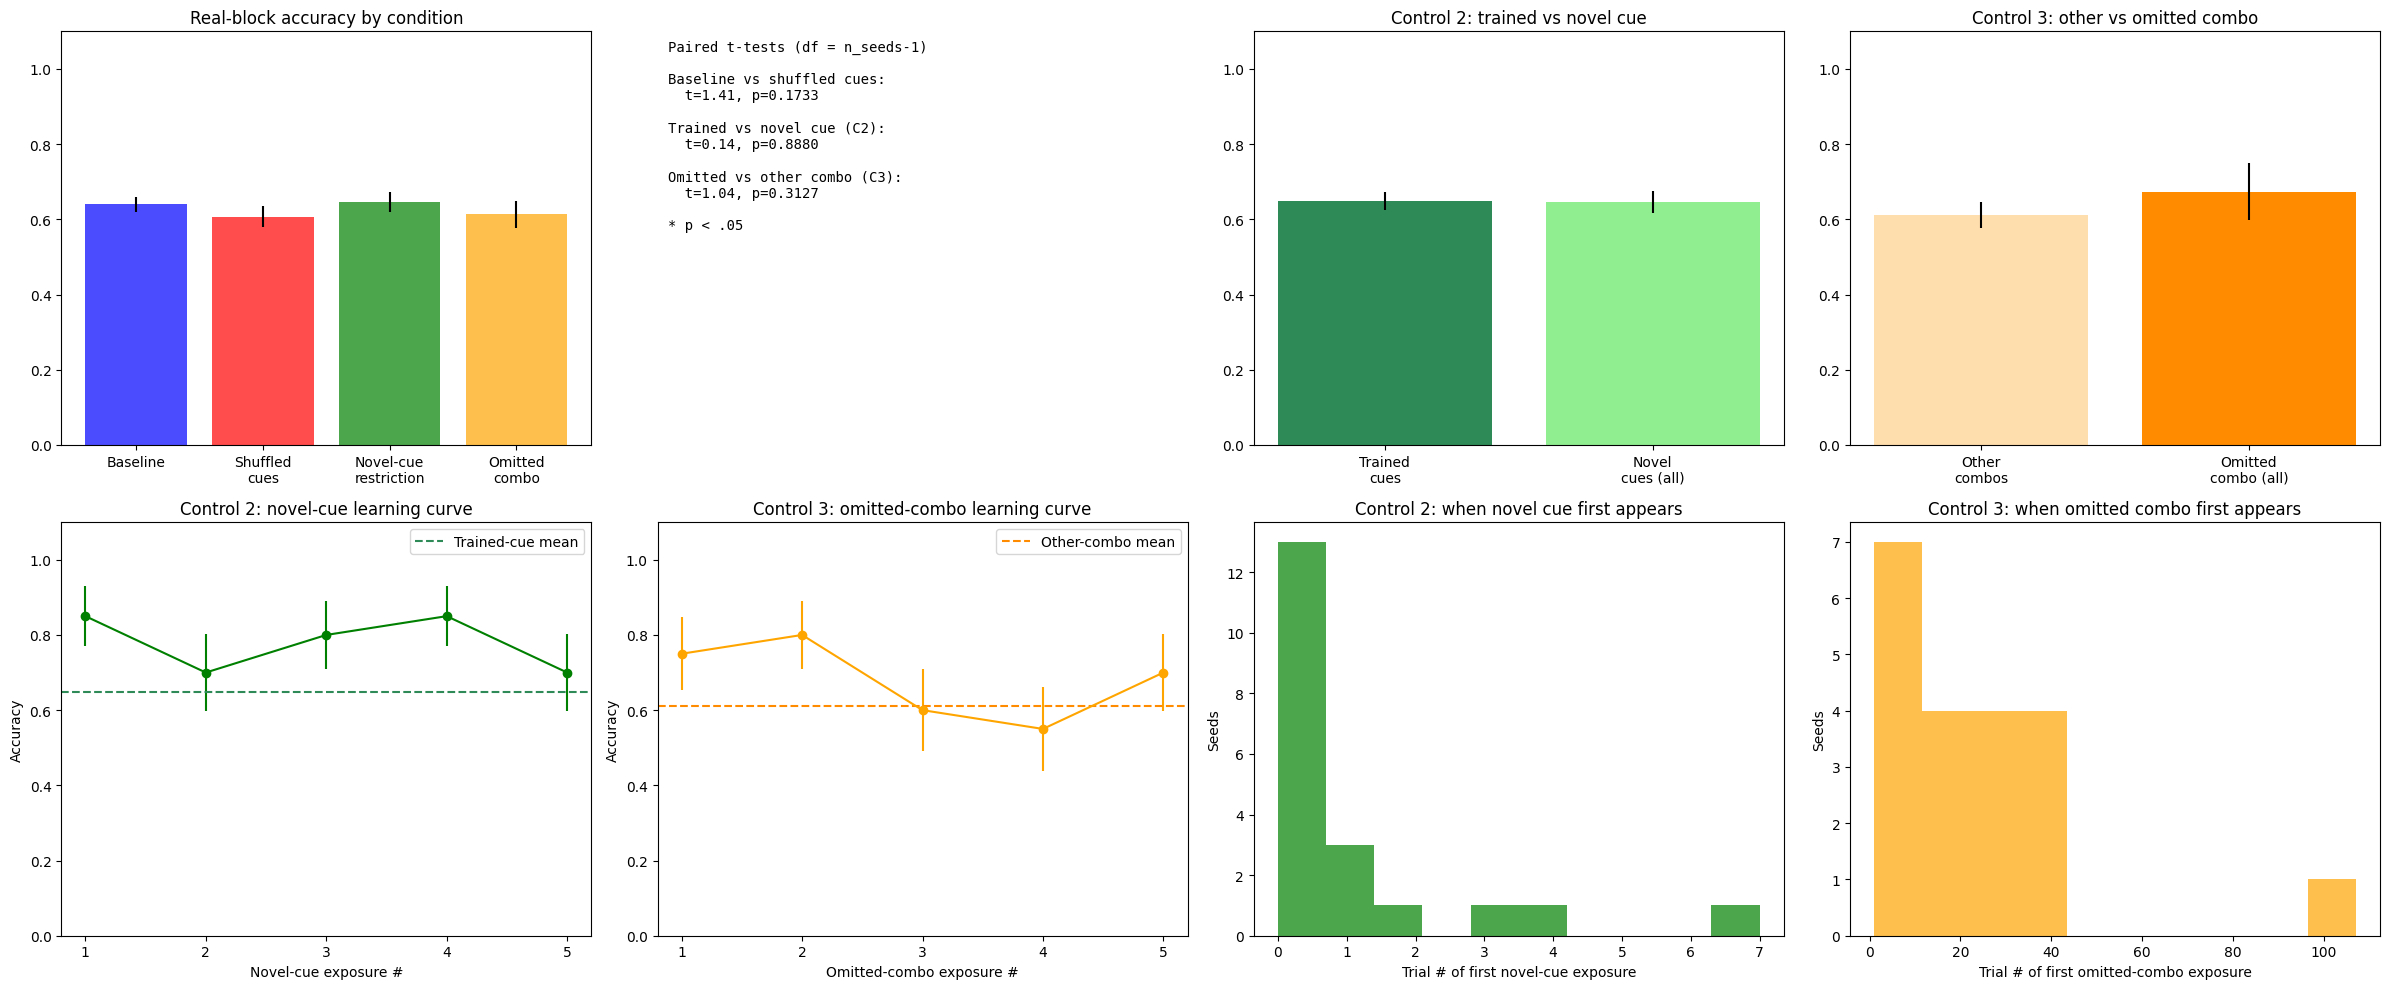


=== SUMMARY ===
Baseline accuracy:              0.640
Shuffled-cue accuracy:          0.607
  -> paired t-test baseline vs shuffled: t=1.415, p=0.17328

Control 2 - trained cues:        0.648
Control 2 - novel cues (all):    0.646
  -> paired t-test trained vs novel: t=0.143, p=0.88797
  -> mean trial of first novel-cue exposure: 0.9
  -> accuracy by novel-cue exposure # (1-5): [0.85, 0.7, 0.8, 0.85, 0.7]

Control 3 - other combos:        0.610
Control 3 - omitted combo (all): 0.674
  -> paired t-test omitted vs other: t=1.037, p=0.31272
  -> mean trial of first omitted-combo exposure: 24.0
  -> accuracy by omitted-combo exposure # (1-5): [0.75, 0.8, 0.6, 0.55, 0.7]
Done: all simulations and plots complete.


In [17]:
"""Cued task-switching plastic-attractor model + Controls 1-3

  1. The instruction-phase teaching signal no longer forces the
     task-irrelevant colour/shape pair to a constant 0.5 for the whole
     ~300-step teaching window -- that was swamping the real signal in the
     Hebbian update and dragging real-block accuracy down to chance.
  2. "First exposure trial number" is computed relative to the start of the
     real/test phase, not the whole session.
Runs are sequential (no multiprocessing) for reliability inside a notebook
kernel -- Colab's CPU count is small anyway, so the parallel speedup would
have been modest.
"""



from __future__ import annotations

import os
from collections.abc import Iterable
from dataclasses import dataclass, field
from enum import Enum, IntEnum
from statistics import fmean

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel




class Feature(IntEnum):
    """Meaning of the four feature-vector positions that never move.

    Cue and action positions shift with num_cues_per_rule, so they aren't fixed
    enum members; see build_vocabulary below.
    """

    GREEN = 0
    BLUE = 1
    SQUARE = 2
    CIRCLE = 3


class Task(str, Enum):
    """The stimulus dimension that determines the correct response (the rule)."""

    COLOR = 'color'
    SHAPE = 'shape'


COLOR_FEATURES = (Feature.GREEN, Feature.BLUE)
SHAPE_FEATURES = (Feature.SQUARE, Feature.CIRCLE)

FEATURES_BY_TASK = {
    Task.COLOR: COLOR_FEATURES,
    Task.SHAPE: SHAPE_FEATURES,
}

IRRELEVANT_FEATURES_BY_TASK = {
    Task.COLOR: SHAPE_FEATURES,
    Task.SHAPE: COLOR_FEATURES,
}


@dataclass(frozen=True)
class Vocabulary:
    """Feature-vector layout for a given number of cues per rule.

    Colour/shape stay fixed at indices 0-3 (Feature enum); the cue block (2
    rules x num_cues_per_rule) and the two action indices after it shift
    position with num_cues_per_rule, so they're plain ints here rather than
    enum members.
    """

    num_cues_per_rule: int
    number_of_features: int
    cues_by_task: dict[Task, tuple[int, ...]]
    response_features: tuple[int, int]
    response_by_feature: dict[Feature, int]
    competing_feature_groups: tuple[tuple[int, ...], ...]


def build_vocabulary(num_cues_per_rule: int = 2) -> Vocabulary:
    """Lay out cue and action positions after the four fixed colour/shape units.

    Order matches the flat attractor_rnn.py script at num_cues_per_rule=2:
    [green, blue, square, circle, cueA1, cueA2, cueB1, cueB2, action1, action2].
    """

    if num_cues_per_rule <= 0:
        raise ValueError('num_cues_per_rule must be positive')

    cue_start = 4
    color_cues = tuple(range(cue_start, cue_start + num_cues_per_rule))
    shape_cues = tuple(
        range(cue_start + num_cues_per_rule, cue_start + 2 * num_cues_per_rule)
    )
    action_1 = cue_start + 2 * num_cues_per_rule
    action_2 = action_1 + 1
    response_features = (action_1, action_2)

    return Vocabulary(
        num_cues_per_rule=num_cues_per_rule,
        number_of_features=action_2 + 1,
        cues_by_task={Task.COLOR: color_cues, Task.SHAPE: shape_cues},
        response_features=response_features,
        response_by_feature={
            Feature.GREEN: action_1, Feature.BLUE: action_2,
            Feature.SQUARE: action_1, Feature.CIRCLE: action_2,
        },
        competing_feature_groups=(
            COLOR_FEATURES, SHAPE_FEATURES, color_cues + shape_cues, response_features,
        ),
    )


def cues_for_task(vocabulary: Vocabulary, task: Task) -> tuple[int, ...]:
    """Return the cues that signal the given rule."""

    return vocabulary.cues_by_task[task]


@dataclass(frozen=True)
class Stimulus:
    """One colour-shape combination presented on a trial."""

    color: Feature
    shape: Feature

    def __post_init__(self) -> None:
        if self.color not in COLOR_FEATURES:
            raise ValueError(f'{self.color!r} is not a colour feature')
        if self.shape not in SHAPE_FEATURES:
            raise ValueError(f'{self.shape!r} is not a shape feature')

    def relevant_feature(self, task: Task) -> Feature:
        """Select the colour or shape according to the current rule."""

        if task == Task.COLOR:
            return self.color
        if task == Task.SHAPE:
            return self.shape
        raise ValueError(f'Unknown task: {task!r}')


ALL_STIMULI = (
    Stimulus(Feature.GREEN, Feature.SQUARE),
    Stimulus(Feature.GREEN, Feature.CIRCLE),
    Stimulus(Feature.BLUE, Feature.SQUARE),
    Stimulus(Feature.BLUE, Feature.CIRCLE),
)


def correct_response(vocabulary: Vocabulary, task: Task, stimulus: Stimulus) -> int:
    """Return the action feature index selected by the current rule."""

    relevant_feature = stimulus.relevant_feature(task)
    return vocabulary.response_by_feature[relevant_feature]


def is_congruent(stimulus: Stimulus) -> bool:
    """Return whether colour and shape indicate the same response."""

    return (stimulus.color == Feature.GREEN) == (stimulus.shape == Feature.SQUARE)


# ==== CELL 3: the network (was model.py) ==== #

@dataclass(frozen=True)
class ModelParameters:
    """Named parameters for the two coupled neural populations."""

    number_of_conjunction_units: int = 4
    num_cues_per_rule: int = 2

    baseline_activity: float = 0.175

    conjunction_lateral_weight: float = -0.45
    conjunction_self_weight: float = 1.00
    feature_lateral_weight: float = -0.28
    feature_self_weight: float = 0.73

    conjunction_to_feature_gain: float = 0.08
    feature_to_conjunction_gain: float = 0.04

    conjunction_noise_standard_deviation: float = 0.005

    fast_learning_rate: float = 0.02
    slow_learning_rate: float = 0.0002
    maximum_fast_weight: float = 1.0
    maximum_slow_weight: float = 0.2

    fast_weight_blend: float = 1.0
    slow_weight_blend: float = 1.0

    def __post_init__(self) -> None:
        if self.number_of_conjunction_units <= 0:
            raise ValueError('number_of_conjunction_units must be positive')
        if self.num_cues_per_rule <= 0:
            raise ValueError('num_cues_per_rule must be positive')
        if not 0.0 <= self.baseline_activity <= 1.0:
            raise ValueError('baseline_activity must lie between 0 and 1')
        if self.conjunction_noise_standard_deviation < 0:
            raise ValueError('Noise standard deviation cannot be negative')
        if self.fast_learning_rate < 0 or self.slow_learning_rate < 0:
            raise ValueError('Learning rates cannot be negative')
        if self.maximum_fast_weight <= 0 or self.maximum_slow_weight <= 0:
            raise ValueError('Maximum weights must be positive')


@dataclass(frozen=True)
class NetworkState:
    """Activity of both neural populations after one update."""

    feature_activity: np.ndarray
    conjunction_activity: np.ndarray


def _bounded_activity(values: np.ndarray) -> np.ndarray:
    """Keep every unit between silence (0) and maximum activity (1)."""

    return np.clip(values, 0.0, 1.0)


class PlasticAttractor:
    """Feature units recurrently coupled to conjunction units."""

    def __init__(
        self,
        seed: int = 0,
        parameters: ModelParameters | None = None,
        learn: bool = True,
        *,
        random_generator: np.random.RandomState | None = None,
    ) -> None:
        self.parameters = parameters or ModelParameters()
        self.learn = learn

        vocabulary = build_vocabulary(self.parameters.num_cues_per_rule)
        self._number_of_feature_units = vocabulary.number_of_features
        self._competing_feature_groups = vocabulary.competing_feature_groups

        self._random = (
            random_generator
            if random_generator is not None
            else np.random.RandomState(seed)
        )

        self._feature_recurrent_weights = self._build_feature_connections()
        self._conjunction_recurrent_weights = self._build_conjunction_connections()
        self._initialize_plastic_weights()

        self._feature_activity = np.zeros(self.number_of_feature_units)
        self._conjunction_activity = np.zeros(self.number_of_conjunction_units)

    @property
    def number_of_feature_units(self) -> int:
        return self._number_of_feature_units

    @property
    def number_of_conjunction_units(self) -> int:
        return self.parameters.number_of_conjunction_units

    @property
    def state(self) -> NetworkState:
        return NetworkState(
            feature_activity=self._feature_activity.copy(),
            conjunction_activity=self._conjunction_activity.copy(),
        )

    @property
    def combined_weights(self) -> np.ndarray:
        return self._combined_weights.copy()

    @property
    def fast_weights(self) -> np.ndarray:
        return self._fast_weights.copy()

    @property
    def slow_weights(self) -> np.ndarray:
        return self._slow_weights.copy()

    def reset_activity(self) -> None:
        self._feature_activity = np.zeros(self.number_of_feature_units)
        self._conjunction_activity = np.zeros(self.number_of_conjunction_units)

    def step(
        self,
        external_input: np.ndarray,
        *,
        clamp_conjunctions: bool = False,
        learn: bool | None = None,
    ) -> NetworkState:
        input_vector = np.asarray(external_input, dtype=float)
        expected_shape = (self.number_of_feature_units,)
        if input_vector.shape != expected_shape:
            raise ValueError(
                f'external_input must have shape {expected_shape}; '
                f'received {input_vector.shape}'
            )

        parameters = self.parameters

        centered_features = self._feature_activity - parameters.baseline_activity
        centered_conjunctions = self._conjunction_activity - parameters.baseline_activity

        next_features = _bounded_activity(
            parameters.baseline_activity
            + self._feature_recurrent_weights @ centered_features
            + parameters.conjunction_to_feature_gain
            * (self._combined_weights @ centered_conjunctions)
            + input_vector
        )

        next_conjunctions = _bounded_activity(
            parameters.baseline_activity
            + self._conjunction_recurrent_weights @ centered_conjunctions
            + parameters.feature_to_conjunction_gain
            * (self._combined_weights.T @ centered_features)
            + parameters.conjunction_noise_standard_deviation
            * self._random.standard_normal(self.number_of_conjunction_units)
        )

        if clamp_conjunctions:
            next_conjunctions.fill(1.0)

        self._feature_activity = next_features
        self._conjunction_activity = next_conjunctions

        learning_is_on = self.learn if learn is None else learn
        if learning_is_on:
            self._update_plastic_weights()

        return self.state

    def feedback_eigenvalues(self) -> np.ndarray:
        return np.linalg.eigvalsh(self._combined_weights @ self._combined_weights.T)

    def number_of_amplifying_eigenvalues(self) -> int:
        return int(np.sum(self.feedback_eigenvalues() > 1.0))

    def _build_feature_connections(self) -> np.ndarray:
        within_dimension = np.zeros(
            (self.number_of_feature_units, self.number_of_feature_units)
        )
        for group in self._competing_feature_groups:
            within_dimension[np.ix_(group, group)] = 1.0

        parameters = self.parameters
        return (
            parameters.feature_self_weight * np.eye(self.number_of_feature_units)
            + parameters.feature_lateral_weight * within_dimension
        )

    def _build_conjunction_connections(self) -> np.ndarray:
        parameters = self.parameters
        return (
            parameters.conjunction_self_weight
            * np.eye(self.number_of_conjunction_units)
            + parameters.conjunction_lateral_weight
            * np.ones(
                (self.number_of_conjunction_units, self.number_of_conjunction_units)
            )
        )

    def _initialize_plastic_weights(self) -> None:
        shape = (self.number_of_feature_units, self.number_of_conjunction_units)
        parameters = self.parameters

        self._fast_weights = self._random.uniform(0.0, parameters.maximum_fast_weight, size=shape)
        self._slow_weights = self._random.uniform(0.0, parameters.maximum_slow_weight, size=shape)
        self._combine_weights()

    def _update_plastic_weights(self) -> None:
        parameters = self.parameters

        change = np.outer(
            self._feature_activity - parameters.baseline_activity,
            self._conjunction_activity - parameters.baseline_activity,
        )

        self._fast_weights = np.clip(
            self._fast_weights + parameters.fast_learning_rate * change,
            0.0, parameters.maximum_fast_weight,
        )
        self._slow_weights = np.clip(
            self._slow_weights + parameters.slow_learning_rate * change,
            0.0, parameters.maximum_slow_weight,
        )
        self._combine_weights()

    def _combine_weights(self) -> None:
        parameters = self.parameters
        self._combined_weights = (
            parameters.fast_weight_blend * self._fast_weights
            + parameters.slow_weight_blend * self._slow_weights
        )


# ==== CELL 4: the experiment (was experiment.py) ==== #

PRACTICE_TASKS = (Task.COLOR, Task.SHAPE)


class TransitionType(IntEnum):
    """How a real trial relates to the previous one in its block."""

    FIRST_TRIAL = -1
    CUE_REPEAT = 0
    CUE_SWITCH_RULE_REPEAT = 1
    RULE_SWITCH = 2


@dataclass(frozen=True)
class TimeWindow:
    """A half-open interval: start is included and stop is excluded."""

    start: int
    stop: int

    def __post_init__(self) -> None:
        if self.start < 0 or self.stop <= self.start:
            raise ValueError('A time window needs 0 <= start < stop')

    def contains(self, time_step: int) -> bool:
        return self.start <= time_step < self.stop

    @property
    def duration(self) -> int:
        return self.stop - self.start


@dataclass(frozen=True)
class EpochProtocol:
    """Per-trial timing, matching the flat attractor_rnn.py schedule."""

    number_of_steps: int = 400
    stimulus_window: TimeWindow = field(default_factory=lambda: TimeWindow(51, 101))
    response_window: TimeWindow = field(default_factory=lambda: TimeWindow(101, 351))
    teaching_window: TimeWindow = field(default_factory=lambda: TimeWindow(50, 351))
    response_search_start: int = 110

    def __post_init__(self) -> None:
        if self.number_of_steps <= 0:
            raise ValueError('number_of_steps must be positive')
        for window in (self.stimulus_window, self.response_window, self.teaching_window):
            if window.stop > self.number_of_steps:
                raise ValueError('Protocol windows must fit inside the epoch')
        if not 0 <= self.response_search_start < self.number_of_steps:
            raise ValueError('response_search_start must lie inside the epoch')


@dataclass(frozen=True)
class ConjunctionClamp:
    """Force every conjunction unit to maximum activity in a time window."""

    window: TimeWindow

    @classmethod
    def between(cls, start: int, stop: int) -> 'ConjunctionClamp':
        return cls(TimeWindow(start, stop))

    @classmethod
    def ending_with_stimulus(cls, duration_in_steps: int, protocol=None) -> 'ConjunctionClamp':
        if duration_in_steps <= 0:
            raise ValueError('duration_in_steps must be positive')
        timing = protocol or EpochProtocol()
        stop = timing.stimulus_window.stop
        start = stop - duration_in_steps
        if start < 0:
            raise ValueError('Clamp duration begins before the epoch')
        return cls.between(start, stop)

    def is_active(self, time_step: int) -> bool:
        return self.window.contains(time_step)

    @property
    def duration_in_steps(self) -> int:
        return self.window.duration


def author_tms_pulse(labeled_dose: int, protocol=None):
    """Translate the flat script's inclusive TMS dose label into a clamp."""

    if labeled_dose < 0:
        raise ValueError('labeled_dose cannot be negative')
    if labeled_dose == 0:
        return None
    return ConjunctionClamp.ending_with_stimulus(duration_in_steps=labeled_dose + 1, protocol=protocol)


@dataclass(frozen=True)
class NetworkTrajectory:
    """Time-by-unit activity recorded during one epoch."""

    feature_activity: np.ndarray
    conjunction_activity: np.ndarray


def run_epoch(model, inputs, protocol, *, perturbation=None, learn=None) -> NetworkTrajectory:
    """Reset activity, run every time step, and record the trajectory."""

    input_array = np.asarray(inputs, dtype=float)
    expected_shape = (protocol.number_of_steps, model.number_of_feature_units)
    if input_array.shape != expected_shape:
        raise ValueError(f'inputs must have shape {expected_shape}; received {input_array.shape}')

    model.reset_activity()

    feature_history = np.empty((protocol.number_of_steps, model.number_of_feature_units))
    conjunction_history = np.empty((protocol.number_of_steps, model.number_of_conjunction_units))

    for time_step in range(protocol.number_of_steps):
        clamp_is_active = perturbation is not None and perturbation.is_active(time_step)
        state = model.step(input_array[time_step], clamp_conjunctions=clamp_is_active, learn=learn)
        feature_history[time_step] = state.feature_activity
        conjunction_history[time_step] = state.conjunction_activity

    return NetworkTrajectory(feature_history, conjunction_history)


@dataclass(frozen=True)
class PlannedTrial:
    task: Task
    cue: int
    stimulus: Stimulus


def _balanced_shuffled_deck(task, permutation_repeats, vocabulary, random_generator, *,
                             allowed_cues=None, omit_combo=None):
    """Every (cue x stimulus) combo for task, tiled permutation_repeats times + shuffled.

    allowed_cues restricts the cue pool below cues_for_task(vocabulary, task)
    (Control 2: novel-cue generalization). omit_combo drops one specific
    (cue, stimulus) pairing from the deck (Control 3).
    """

    cues = allowed_cues if allowed_cues is not None else cues_for_task(vocabulary, task)
    combos = [
        (cue, stimulus)
        for cue in cues
        for stimulus in ALL_STIMULI
        if omit_combo is None or (cue, stimulus) != omit_combo
    ]
    if not combos:
        raise ValueError('No (cue, stimulus) combinations remain after allowed_cues/omit_combo')
    combos = combos * permutation_repeats
    order = random_generator.permutation(len(combos))
    return [combos[i] for i in order]


def practice_block_plan(task, permutation_repeats, vocabulary, random_generator, *,
                         allowed_cues=None, omit_combo=None):
    """Plan one practice block: every (cue x stimulus) combo, tiled + shuffled."""

    if permutation_repeats <= 0:
        raise ValueError('practice_permutation_repeats must be positive')

    deck = _balanced_shuffled_deck(
        task, permutation_repeats, vocabulary, random_generator,
        allowed_cues=allowed_cues, omit_combo=omit_combo,
    )
    return [PlannedTrial(task, cue, stimulus) for cue, stimulus in deck]


def switching_practice_block_plan(switch_probability, permutation_repeats, vocabulary, random_generator, *,
                                   allowed_cues_by_task=None, omit_combo=None):
    """Plan one practice block that may switch rule mid-block, like a real block."""

    if permutation_repeats <= 0:
        raise ValueError('practice_permutation_repeats must be positive')
    if not 0.0 <= switch_probability <= 1.0:
        raise ValueError('switch_probability must lie between 0 and 1')

    decks = {
        task: _balanced_shuffled_deck(
            task, permutation_repeats, vocabulary, random_generator,
            allowed_cues=(allowed_cues_by_task.get(task) if allowed_cues_by_task is not None else None),
            omit_combo=omit_combo,
        )
        for task in PRACTICE_TASKS
    }
    total_trials = sum(len(deck) for deck in decks.values())

    current_task = PRACTICE_TASKS[random_generator.randint(len(PRACTICE_TASKS))]
    plan: list[PlannedTrial] = []
    for _ in range(total_trials):
        if random_generator.rand() < switch_probability:
            other = PRACTICE_TASKS[1 - PRACTICE_TASKS.index(current_task)]
            if decks[other]:
                current_task = other
        if not decks[current_task]:
            current_task = next(task for task in PRACTICE_TASKS if decks[task])

        cue, stimulus = decks[current_task].pop(0)
        plan.append(PlannedTrial(current_task, cue, stimulus))

    return plan


def _draw_cue_avoiding_combo(task_cues, stimulus, omit_combo, random_generator) -> int:
    """Draw one cue uniformly from task_cues, resampling to avoid recreating
    omit_combo when it's paired with this trial's stimulus."""

    if omit_combo is None or omit_combo[1] != stimulus:
        return task_cues[random_generator.randint(len(task_cues))]

    remaining = tuple(cue for cue in task_cues if cue != omit_combo[0])
    if not remaining:
        raise ValueError(
            'omit_practice_combo leaves no valid cue for this stimulus in a '
            'block drawn from real_block_plan (e.g. performance practice); '
            'set include_performance_practice=False or allow another cue for this rule.'
        )
    return remaining[random_generator.randint(len(remaining))]


def real_block_plan(switch_probability, num_trials, vocabulary, random_generator, initial_task=None, *,
                     allowed_cues_by_task=None, omit_combo=None, shuffle_cues=False):
    """Plan one real block: rule switches w.p. switch_probability, cue signals it."""

    if num_trials <= 0 or num_trials % 4:
        raise ValueError('num_trials must be a positive multiple of 4')
    if not 0.0 <= switch_probability <= 1.0:
        raise ValueError('switch_probability must lie between 0 and 1')

    first_task = initial_task if initial_task is not None else PRACTICE_TASKS[random_generator.randint(2)]
    tasks: list[Task] = [first_task]
    for _ in range(1, num_trials):
        if random_generator.rand() < switch_probability:
            other = 1 - PRACTICE_TASKS.index(tasks[-1])
            tasks.append(PRACTICE_TASKS[other])
        else:
            tasks.append(tasks[-1])

    stimulus_indices = np.tile(np.arange(len(ALL_STIMULI)), num_trials // 4)
    random_generator.shuffle(stimulus_indices)
    stimuli = [ALL_STIMULI[int(index)] for index in stimulus_indices]

    cues = []
    for task, stimulus in zip(tasks, stimuli):
        task_cues = (
            allowed_cues_by_task.get(task, cues_for_task(vocabulary, task))
            if allowed_cues_by_task is not None
            else cues_for_task(vocabulary, task)
        )
        cues.append(_draw_cue_avoiding_combo(task_cues, stimulus, omit_combo, random_generator))

    if shuffle_cues:
        cues = list(cues)
        random_generator.shuffle(cues)

    return [PlannedTrial(task, cue, stimulus) for task, cue, stimulus in zip(tasks, cues, stimuli)]


def _transition_type(plan, index) -> TransitionType:
    """Classify trial `index` relative to its predecessor in the same block."""

    if index == 0:
        return TransitionType.FIRST_TRIAL
    previous, current = plan[index - 1], plan[index]
    if current.task != previous.task:
        return TransitionType.RULE_SWITCH
    if current.cue != previous.cue:
        return TransitionType.CUE_SWITCH_RULE_REPEAT
    return TransitionType.CUE_REPEAT


@dataclass(frozen=True)
class SwitchingExperimentConfig:
    """Every choice needed to reproduce one cued-switching simulation."""

    seed: int = 0
    num_practice_blocks: int = 2
    practice_permutation_repeats: int = 1
    practice_switch_probability: float = 0.0
    include_performance_practice: bool = True
    num_trials: int = 48
    switch_probs: tuple[float, ...] = (0.125, 0.25, 0.5, 0.75) * 2
    protocol: EpochProtocol = field(default_factory=EpochProtocol)
    model_parameters: ModelParameters = field(default_factory=ModelParameters)
    perturbation: ConjunctionClamp | None = None
    learn_during_trials: bool = True

    # --- Experimental controls, all off (baseline) by default --- #
    shuffle_cues_test: bool = False
    practice_cue_restriction: dict[Task, tuple[int, ...]] | None = None
    omit_practice_combo: tuple[int, Stimulus] | None = None

    def __post_init__(self) -> None:
        if self.practice_switch_probability == 0.0:
            if not 1 <= self.num_practice_blocks <= len(PRACTICE_TASKS):
                raise ValueError(
                    f'num_practice_blocks must be between 1 and {len(PRACTICE_TASKS)} '
                    'when practice_switch_probability is 0'
                )
        elif self.num_practice_blocks < 1:
            raise ValueError('num_practice_blocks must be positive')
        if self.practice_permutation_repeats <= 0:
            raise ValueError('practice_permutation_repeats must be positive')
        if not 0.0 <= self.practice_switch_probability <= 1.0:
            raise ValueError('practice_switch_probability must lie between 0 and 1')
        if not self.switch_probs:
            raise ValueError('switch_probs needs at least one real block')
        if self.perturbation is not None and self.perturbation.window.stop > self.protocol.number_of_steps:
            raise ValueError('perturbation window must fit inside the epoch')
        if self.practice_cue_restriction is not None:
            vocabulary = build_vocabulary(self.model_parameters.num_cues_per_rule)
            for task, cues in self.practice_cue_restriction.items():
                if task not in PRACTICE_TASKS:
                    raise ValueError(f'practice_cue_restriction has unknown task {task!r}')
                if not cues:
                    raise ValueError(f'practice_cue_restriction for {task!r} must not be empty')
                valid_cues = set(cues_for_task(vocabulary, task))
                if not set(cues) <= valid_cues:
                    raise ValueError(f'practice_cue_restriction for {task!r} must be a subset of {valid_cues}')
        if self.omit_practice_combo is not None:
            cue, stimulus = self.omit_practice_combo
            if not isinstance(stimulus, Stimulus):
                raise ValueError('omit_practice_combo must be (cue_index, Stimulus)')

    @property
    def practice_trials(self) -> int:
        per_rule = self.practice_permutation_repeats * self.model_parameters.num_cues_per_rule * len(ALL_STIMULI)
        return per_rule * (2 if self.practice_switch_probability > 0.0 else 1)

    @property
    def number_of_blocks(self) -> int:
        performance_practice_blocks = len(PRACTICE_TASKS) if self.include_performance_practice else 0
        return self.num_practice_blocks + performance_practice_blocks + len(self.switch_probs)


@dataclass(frozen=True)
class TrialResult:
    """Behaviour and neural activity recorded for one trial."""

    seed: int
    block_index: int
    trial_index_in_block: int
    is_practice: bool
    is_instruction: bool
    switch_probability: float | None
    task: Task
    cue: int
    stimulus: Stimulus
    correct_response: int
    chosen_response: int | None
    reaction_time_in_steps: float
    transition_type: TransitionType
    perturbation: ConjunctionClamp | None
    trajectory: NetworkTrajectory
    combined_weights: np.ndarray

    @property
    def correct(self) -> bool:
        return self.chosen_response is not None and self.chosen_response == self.correct_response

    @property
    def congruent(self) -> bool:
        return is_congruent(self.stimulus)


@dataclass(frozen=True)
class ExperimentResult:
    """Trial-level data and final summaries from one cued-switching experiment."""

    config: SwitchingExperimentConfig
    trials: tuple[TrialResult, ...]
    amplifying_eigenvalue_count_by_block: tuple[int, ...]
    final_combined_weights: np.ndarray


def _stimulus_vector(stimulus, vocabulary) -> np.ndarray:
    vector = np.zeros(vocabulary.number_of_features)
    vector[stimulus.color] = 1.0
    vector[stimulus.shape] = 1.0
    return vector


def _cue_vector(cue, vocabulary) -> np.ndarray:
    vector = np.zeros(vocabulary.number_of_features)
    vector[cue] = 1.0
    return vector


def _teaching_drive(correct, vocabulary) -> np.ndarray:
    """+1 on the correct action unit, -1 on the others."""

    return np.array([1.0 if action == correct else -1.0 for action in vocabulary.response_features])


def _trial_epoch(planned, apply_teaching, protocol, vocabulary) -> np.ndarray:
    """Build the full external-input schedule (steps x features) for one trial.

    Deliberately does NOT drive the task-irrelevant colour/shape pair to a
    neutral value during teaching (see module docstring, fix 1).
    """

    inputs = np.zeros((protocol.number_of_steps, vocabulary.number_of_features))

    inputs[: protocol.stimulus_window.start] = -1.0
    inputs[protocol.response_window.stop :] = -1.0

    stimulus_window = protocol.stimulus_window
    inputs[stimulus_window.start : stimulus_window.stop] = (
        _stimulus_vector(planned.stimulus, vocabulary) + _cue_vector(planned.cue, vocabulary)
    )

    if apply_teaching:
        correct = correct_response(vocabulary, planned.task, planned.stimulus)
        teaching_window = protocol.teaching_window
        inputs[
            teaching_window.start : teaching_window.stop,
            list(vocabulary.response_features),
        ] = _teaching_drive(correct, vocabulary)

    return inputs


def _measure_response(trajectory, protocol, vocabulary):
    """Apply the flat script's global-peak and 98%-of-peak response rule."""

    eligible_activity = trajectory.feature_activity[
        protocol.response_search_start :, list(vocabulary.response_features)
    ]
    global_peak = float(eligible_activity.max())
    if not np.isfinite(global_peak) or global_peak <= 0.0:
        return None, float('nan')

    above_threshold = np.argwhere(eligible_activity.T > 0.98 * global_peak)
    if not above_threshold.size:
        return None, float('nan')

    response_index, first_time = above_threshold[0]
    return vocabulary.response_features[int(response_index)], float(first_time)


def _run_trial(model, config, vocabulary, block_index, trial_index, is_practice, apply_teaching,
               switch_probability, planned, transition_type) -> TrialResult:
    trajectory = run_epoch(
        model, _trial_epoch(planned, apply_teaching, config.protocol, vocabulary), config.protocol,
        perturbation=config.perturbation, learn=config.learn_during_trials,
    )
    chosen_response, reaction_time = _measure_response(trajectory, config.protocol, vocabulary)

    return TrialResult(
        seed=config.seed, block_index=block_index, trial_index_in_block=trial_index,
        is_practice=is_practice, is_instruction=apply_teaching, switch_probability=switch_probability,
        task=planned.task, cue=planned.cue, stimulus=planned.stimulus,
        correct_response=correct_response(vocabulary, planned.task, planned.stimulus),
        chosen_response=chosen_response, reaction_time_in_steps=reaction_time,
        transition_type=transition_type, perturbation=config.perturbation,
        trajectory=trajectory, combined_weights=model.combined_weights,
    )


def _run_block(model, config, vocabulary, block_index, is_practice, apply_teaching,
               switch_probability, plan) -> list[TrialResult]:
    return [
        _run_trial(
            model=model, config=config, vocabulary=vocabulary, block_index=block_index,
            trial_index=trial_index, is_practice=is_practice, apply_teaching=apply_teaching,
            switch_probability=switch_probability, planned=planned,
            transition_type=_transition_type(plan, trial_index),
        )
        for trial_index, planned in enumerate(plan)
    ]


def run_switching_experiment(config: SwitchingExperimentConfig) -> ExperimentResult:
    """Run instruction, then performance practice, then the cued real blocks."""

    vocabulary = build_vocabulary(config.model_parameters.num_cues_per_rule)

    random_generator = np.random.RandomState(config.seed)
    model = PlasticAttractor(parameters=config.model_parameters, random_generator=random_generator)

    trials: list[TrialResult] = []
    eigenvalue_counts: list[int] = []

    # instruction blocks: teach with the action-teaching drive.
    # practice_cue_restriction / omit_practice_combo (Controls 2 and 3) apply
    # here so the restricted cue or omitted combo is never taught.
    for block_index in range(config.num_practice_blocks):
        if config.practice_switch_probability > 0.0:
            plan = switching_practice_block_plan(
                config.practice_switch_probability, config.practice_permutation_repeats,
                vocabulary, random_generator,
                allowed_cues_by_task=config.practice_cue_restriction, omit_combo=config.omit_practice_combo,
            )
        else:
            task = PRACTICE_TASKS[block_index]
            allowed_cues = (
                config.practice_cue_restriction.get(task) if config.practice_cue_restriction is not None else None
            )
            plan = practice_block_plan(
                task, config.practice_permutation_repeats, vocabulary, random_generator,
                allowed_cues=allowed_cues, omit_combo=config.omit_practice_combo,
            )
        trials.extend(_run_block(
            model, config, vocabulary, block_index,
            is_practice=True, apply_teaching=True, switch_probability=None, plan=plan,
        ))
        eigenvalue_counts.append(model.number_of_amplifying_eigenvalues())

    # performance-practice blocks: same restriction/omission carries over,
    # otherwise a "novel" cue or combo would already be trained on by the
    # time the real switching blocks run.
    if config.include_performance_practice:
        for practice_index, task in enumerate(PRACTICE_TASKS):
            block_index = config.num_practice_blocks + practice_index
            plan = real_block_plan(
                switch_probability=0.0, num_trials=config.num_trials, vocabulary=vocabulary,
                random_generator=random_generator, initial_task=task,
                allowed_cues_by_task=config.practice_cue_restriction, omit_combo=config.omit_practice_combo,
            )
            trials.extend(_run_block(
                model, config, vocabulary, block_index,
                is_practice=True, apply_teaching=False, switch_probability=None, plan=plan,
            ))
            eigenvalue_counts.append(model.number_of_amplifying_eigenvalues())

    # real (test) blocks: always unrestricted and complete -- Controls 2/3
    # only touch what's taught, not what's tested. shuffle_cues_test
    # (Control 1) applies only here.
    performance_practice_blocks = len(PRACTICE_TASKS) if config.include_performance_practice else 0
    for real_index, switch_probability in enumerate(config.switch_probs):
        block_index = config.num_practice_blocks + performance_practice_blocks + real_index
        plan = real_block_plan(
            switch_probability, config.num_trials, vocabulary, random_generator,
            shuffle_cues=config.shuffle_cues_test,
        )
        trials.extend(_run_block(
            model, config, vocabulary, block_index,
            is_practice=False, apply_teaching=False, switch_probability=switch_probability, plan=plan,
        ))
        eigenvalue_counts.append(model.number_of_amplifying_eigenvalues())

    return ExperimentResult(
        config=config, trials=tuple(trials),
        amplifying_eigenvalue_count_by_block=tuple(eigenvalue_counts),
        final_combined_weights=model.combined_weights,
    )


# ==== CELL 5: analysis (was analysis.py) ==== #

@dataclass(frozen=True)
class BehavioralSummary:
    """The main accuracy and reaction-time measurements."""

    accuracy: float
    mean_reaction_time_in_steps: float
    congruent_reaction_time_in_steps: float
    incongruent_reaction_time_in_steps: float

    @property
    def congruency_effect_in_steps(self) -> float:
        return self.incongruent_reaction_time_in_steps - self.congruent_reaction_time_in_steps


@dataclass(frozen=True)
class Contrast:
    """A hard-vs-easy comparison. Costs are signed so a positive number
    always means the harder condition was worse."""

    rt_cost: float
    accuracy_cost: float
    hard_rt: float
    easy_rt: float
    hard_accuracy: float
    easy_accuracy: float


def _mean_or_nan(values) -> float:
    return fmean(values) if values else float('nan')


def summarize_behavior(trials: Iterable[TrialResult]) -> BehavioralSummary:
    """Calculate accuracy and correct-trial reaction-time summaries."""

    trial_list = list(trials)
    if not trial_list:
        raise ValueError('At least one trial is required')

    correct_trials = [trial for trial in trial_list if trial.correct]
    congruent_times = [t.reaction_time_in_steps for t in correct_trials if t.congruent]
    incongruent_times = [t.reaction_time_in_steps for t in correct_trials if not t.congruent]

    return BehavioralSummary(
        accuracy=sum(t.correct for t in trial_list) / len(trial_list),
        mean_reaction_time_in_steps=_mean_or_nan([t.reaction_time_in_steps for t in correct_trials]),
        congruent_reaction_time_in_steps=_mean_or_nan(congruent_times),
        incongruent_reaction_time_in_steps=_mean_or_nan(incongruent_times),
    )


def _contrast(trials, is_hard, is_easy) -> Contrast:
    """RT and accuracy comparison between a hard and an easy trial group."""

    hard = [t for t in trials if is_hard(t)]
    easy = [t for t in trials if is_easy(t)]

    hard_rt = _mean_or_nan([t.reaction_time_in_steps for t in hard if t.correct])
    easy_rt = _mean_or_nan([t.reaction_time_in_steps for t in easy if t.correct])
    hard_accuracy = _mean_or_nan([float(t.correct) for t in hard])
    easy_accuracy = _mean_or_nan([float(t.correct) for t in easy])

    return Contrast(
        rt_cost=hard_rt - easy_rt, accuracy_cost=easy_accuracy - hard_accuracy,
        hard_rt=hard_rt, easy_rt=easy_rt, hard_accuracy=hard_accuracy, easy_accuracy=easy_accuracy,
    )


def performance_by_block(result: ExperimentResult):
    """Mean RT (correct trials) and accuracy for every block, in block order."""

    number_of_blocks = result.config.number_of_blocks
    reaction_time = np.full(number_of_blocks, np.nan)
    accuracy = np.full(number_of_blocks, np.nan)

    for block_index in range(number_of_blocks):
        block_trials = [t for t in result.trials if t.block_index == block_index]
        if not block_trials:
            continue
        reaction_time[block_index] = _mean_or_nan([t.reaction_time_in_steps for t in block_trials if t.correct])
        accuracy[block_index] = _mean_or_nan([float(t.correct) for t in block_trials])

    return reaction_time, accuracy


def no_response_rate_by_block(result: ExperimentResult) -> np.ndarray:
    """Fraction of trials per block with no measurable response."""

    number_of_blocks = result.config.number_of_blocks
    rate = np.full(number_of_blocks, np.nan)

    for block_index in range(number_of_blocks):
        block_trials = [t for t in result.trials if t.block_index == block_index]
        if not block_trials:
            continue
        rate[block_index] = _mean_or_nan([float(t.chosen_response is None) for t in block_trials])

    return rate


# --- Controls 2 and 3: novel cue / omitted combo classification --- #
# Controls 2/3 only change what's taught; the real (test) blocks always
# include every cue and every combo. novel_cue_exposure_sequence and
# omitted_combo_exposure_sequence return the matching real trials in
# encounter order, so accuracy-by-exposure-number is available (the network
# keeps learning during testing, so first-vs-later isn't enough on its own).

def _is_novel_cue(trial: TrialResult, restriction: dict) -> bool:
    trained = restriction.get(trial.task)
    return trained is not None and trial.cue not in trained


def _is_trained_cue(trial: TrialResult, restriction: dict) -> bool:
    trained = restriction.get(trial.task)
    return trained is not None and trial.cue in trained


def novel_cue_contrast(result: ExperimentResult) -> Contrast:
    """Novel-cue vs trained-cue contrast (Control 2) among real trials."""

    restriction = result.config.practice_cue_restriction
    if restriction is None:
        raise ValueError('novel_cue_contrast requires practice_cue_restriction')

    real_trials = [t for t in result.trials if not t.is_practice]
    return _contrast(
        real_trials,
        is_hard=lambda t: _is_novel_cue(t, restriction),
        is_easy=lambda t: _is_trained_cue(t, restriction),
    )


def novel_cue_exposure_sequence(result: ExperimentResult) -> list[TrialResult]:
    """Real trials on a novel cue (Control 2), in encounter order."""

    restriction = result.config.practice_cue_restriction
    if restriction is None:
        raise ValueError('novel_cue_exposure_sequence requires practice_cue_restriction')

    return [t for t in result.trials if not t.is_practice and _is_novel_cue(t, restriction)]


def omitted_combo_contrast(result: ExperimentResult) -> Contrast:
    """Omitted-combo vs other-combo contrast (Control 3) among real trials."""

    omit_combo = result.config.omit_practice_combo
    if omit_combo is None:
        raise ValueError('omitted_combo_contrast requires omit_practice_combo')

    real_trials = [t for t in result.trials if not t.is_practice]
    return _contrast(
        real_trials,
        is_hard=lambda t: (t.cue, t.stimulus) == omit_combo,
        is_easy=lambda t: (t.cue, t.stimulus) != omit_combo,
    )


def omitted_combo_exposure_sequence(result: ExperimentResult) -> list[TrialResult]:
    """Real trials reproducing the omitted (cue, stimulus) combo (Control 3),
    in encounter order."""

    omit_combo = result.config.omit_practice_combo
    if omit_combo is None:
        raise ValueError('omitted_combo_exposure_sequence requires omit_practice_combo')

    return [t for t in result.trials if not t.is_practice and (t.cue, t.stimulus) == omit_combo]


# ==== CELL 6: named parameter sets (was model_versions_config.py) ==== #

num_cues_per_rule = 2
number_of_conjunction_units = 4

_baseline_conjunction_units = 4
_baseline_conjunction_lateral_weight = -0.45


def _rescaled_conjunction_lateral_weight(n_conjunction_units):
    return _baseline_conjunction_lateral_weight * _baseline_conjunction_units / n_conjunction_units


model_versions = {
    'whyte_params_2cpr': ModelParameters(
        number_of_conjunction_units=number_of_conjunction_units, num_cues_per_rule=num_cues_per_rule,
        conjunction_lateral_weight=-0.45, conjunction_self_weight=1.0, conjunction_to_feature_gain=0.08,
        feature_lateral_weight=-0.28, feature_self_weight=0.73, feature_to_conjunction_gain=0.04,
        baseline_activity=0.175, fast_learning_rate=0.02, slow_learning_rate=0.0002,
        maximum_fast_weight=1.0, maximum_slow_weight=0.2, fast_weight_blend=1.0, slow_weight_blend=1.0,
    ),
    '2cpr_Wslow_cap_high': ModelParameters(
        number_of_conjunction_units=number_of_conjunction_units, num_cues_per_rule=num_cues_per_rule,
        conjunction_lateral_weight=-0.45, conjunction_self_weight=1.0, conjunction_to_feature_gain=0.08,
        feature_lateral_weight=-0.28, feature_self_weight=0.73, feature_to_conjunction_gain=0.04,
        baseline_activity=0.175, fast_learning_rate=0.02, slow_learning_rate=0.0002,
        maximum_fast_weight=1.0, maximum_slow_weight=0.7, fast_weight_blend=1.0, slow_weight_blend=1.0,
    ),
    '2cpr_Wslow_cap_high2': ModelParameters(
        number_of_conjunction_units=number_of_conjunction_units, num_cues_per_rule=num_cues_per_rule,
        conjunction_lateral_weight=-0.45, conjunction_self_weight=1.0, conjunction_to_feature_gain=0.08,
        feature_lateral_weight=-0.28, feature_self_weight=0.73, feature_to_conjunction_gain=0.04,
        baseline_activity=0.175, fast_learning_rate=0.02, slow_learning_rate=0.0002,
        maximum_fast_weight=0.2, maximum_slow_weight=1, fast_weight_blend=1.0, slow_weight_blend=1.0,
    ),
    'V1_1cpr_4conj': ModelParameters(
        number_of_conjunction_units=4, num_cues_per_rule=1,
        conjunction_lateral_weight=-0.45, conjunction_self_weight=1.0, conjunction_to_feature_gain=0.08,
        feature_lateral_weight=-0.28, feature_self_weight=0.73, feature_to_conjunction_gain=0.04,
        baseline_activity=0.175, fast_learning_rate=0.02, slow_learning_rate=0.0002,
        maximum_fast_weight=1.0, maximum_slow_weight=0.2, fast_weight_blend=1.0, slow_weight_blend=1.0,
    ),
    'V1b_1cpr_6conj': ModelParameters(
        number_of_conjunction_units=6, num_cues_per_rule=1,
        conjunction_lateral_weight=_rescaled_conjunction_lateral_weight(6), conjunction_self_weight=1.0,
        conjunction_to_feature_gain=0.08, feature_lateral_weight=-0.28, feature_self_weight=0.73,
        feature_to_conjunction_gain=0.04, baseline_activity=0.175, fast_learning_rate=0.02,
        slow_learning_rate=0.0002, maximum_fast_weight=1.0, maximum_slow_weight=0.2,
        fast_weight_blend=1.0, slow_weight_blend=1.0,
    ),
    'V2_2cpr_6conj': ModelParameters(
        number_of_conjunction_units=6, num_cues_per_rule=2,
        conjunction_lateral_weight=_rescaled_conjunction_lateral_weight(6), conjunction_self_weight=1.0,
        conjunction_to_feature_gain=0.08, feature_lateral_weight=-0.28, feature_self_weight=0.73,
        feature_to_conjunction_gain=0.04, baseline_activity=0.175, fast_learning_rate=0.02,
        slow_learning_rate=0.0002, maximum_fast_weight=1.0, maximum_slow_weight=0.2,
        fast_weight_blend=1.0, slow_weight_blend=1.0,
    ),
    'V3_2cpr_8conj': ModelParameters(
        number_of_conjunction_units=8, num_cues_per_rule=2,
        conjunction_lateral_weight=_rescaled_conjunction_lateral_weight(8), conjunction_self_weight=1.0,
        conjunction_to_feature_gain=0.08, feature_lateral_weight=-0.28, feature_self_weight=0.73,
        feature_to_conjunction_gain=0.04, baseline_activity=0.175, fast_learning_rate=0.02,
        slow_learning_rate=0.0002, maximum_fast_weight=1.0, maximum_slow_weight=0.2,
        fast_weight_blend=1.0, slow_weight_blend=1.0,
    ),
}


# ==== CELL 7: run baseline + Controls 1-3 and plot ==== #

output_dir = os.path.join(os.getcwd(), 'output', 'controls')

# lower these first if you just want a quick smoke test (e.g. num_trials=8,
# practice_permutation_repeats=1, n_seeds=2) before committing to a full run
num_trials = 48
practice_permutation_repeats = 5
switch_probs = (0.125, 0.25, 0.5, 0.75) * 2
n_seeds = 20
n_exposure_bins = 5
model_parameters = model_versions['whyte_params_2cpr']

vocabulary = build_vocabulary(model_parameters.num_cues_per_rule)
color_cues = cues_for_task(vocabulary, Task.COLOR)
shape_cues = cues_for_task(vocabulary, Task.SHAPE)

# Control 2: teach only the first cue of each rule; the other cue stays
# novel until the real (test) blocks.
practice_cue_restriction = {Task.COLOR: (color_cues[0],), Task.SHAPE: (shape_cues[0],)}
# Control 3: omit one (cue, stimulus) pairing from every practice /
# performance-practice block.
omit_practice_combo = (color_cues[0], ALL_STIMULI[0])


def build_configs(**overrides):
    return [
        SwitchingExperimentConfig(
            seed=seed, num_trials=num_trials, practice_permutation_repeats=practice_permutation_repeats,
            switch_probs=switch_probs, model_parameters=model_parameters, **overrides,
        )
        for seed in range(n_seeds)
    ]


def run_seeds(configs, label=''):
    # sequential (no multiprocessing) -- more reliable inside a notebook
    # kernel, and Colab's CPU count is small enough that parallel speedup
    # would have been modest anyway
    results = []
    for i, config in enumerate(configs, start=1):
        results.append(run_switching_experiment(config))
        if i % 5 == 0 or i == len(configs):
            print(f'  {label} seed {i}/{len(configs)} done')
    return results


def real_accuracy(result):
    """Accuracy over real (test) trials only, excluding practice/performance
    practice."""

    real_trials = [t for t in result.trials if not t.is_practice]
    return summarize_behavior(real_trials).accuracy


def exposure_curve(sequences, n_bins=n_exposure_bins):
    """Mean +/- SEM accuracy at each exposure number (1st, 2nd, ...)."""

    bins = [[] for _ in range(n_bins)]
    for sequence in sequences:
        for i, trial in enumerate(sequence[:n_bins]):
            bins[i].append(float(trial.correct))
    means = [np.mean(b) if b else np.nan for b in bins]
    sters = [np.std(b) / np.sqrt(len(b)) if b else np.nan for b in bins]
    return means, sters


def first_exposure_trial_index(sequence, config):
    """Trial number within the real/test phase (0 = first trial of the first
    real block) of the first trial in sequence."""

    performance_practice_blocks = 2 if config.include_performance_practice else 0
    real_blocks_start = config.num_practice_blocks + performance_practice_blocks
    first = sequence[0]
    return (first.block_index - real_blocks_start) * num_trials + first.trial_index_in_block


os.makedirs(output_dir, exist_ok=True)

print('Running baseline...')
baseline_results = run_seeds(build_configs(), label='baseline')

print('Running Control 1 (shuffled cues at test)...')
control1_results = run_seeds(build_configs(shuffle_cues_test=True), label='control1')

print('Running Control 2 (novel cue generalization)...')
control2_results = run_seeds(build_configs(practice_cue_restriction=practice_cue_restriction), label='control2')

print('Running Control 3 (omitted combo)...')
control3_results = run_seeds(build_configs(omit_practice_combo=omit_practice_combo), label='control3')
print('All simulations complete.\n')

# ---------------- ACCURACY + SIGNIFICANCE ----------------
seed_acc_baseline = np.array([real_accuracy(r) for r in baseline_results])
seed_acc_c1 = np.array([real_accuracy(r) for r in control1_results])
seed_acc_c2 = np.array([real_accuracy(r) for r in control2_results])
seed_acc_c3 = np.array([real_accuracy(r) for r in control3_results])

t_shuffle, p_shuffle = ttest_rel(seed_acc_baseline, seed_acc_c1)

c2_contrasts = [novel_cue_contrast(r) for r in control2_results]
trained_acc_c2 = np.array([c.easy_accuracy for c in c2_contrasts])
novel_acc_c2 = np.array([c.hard_accuracy for c in c2_contrasts])
t_novel, p_novel = ttest_rel(trained_acc_c2, novel_acc_c2)

c3_contrasts = [omitted_combo_contrast(r) for r in control3_results]
other_acc_c3 = np.array([c.easy_accuracy for c in c3_contrasts])
omitted_acc_c3 = np.array([c.hard_accuracy for c in c3_contrasts])
t_omit, p_omit = ttest_rel(omitted_acc_c3, other_acc_c3)

# ---------------- EXPOSURE CURVES ----------------
novel_sequences = [novel_cue_exposure_sequence(r) for r in control2_results]
novel_exposure_mean, novel_exposure_ster = exposure_curve(novel_sequences)
first_novel_trial = [
    first_exposure_trial_index(seq, r.config) for seq, r in zip(novel_sequences, control2_results) if seq
]

omitted_sequences = [omitted_combo_exposure_sequence(r) for r in control3_results]
omitted_exposure_mean, omitted_exposure_ster = exposure_curve(omitted_sequences)
first_omitted_trial = [
    first_exposure_trial_index(seq, r.config) for seq, r in zip(omitted_sequences, control3_results) if seq
]

# ---------------- PLOTS ----------------
fig, ax = plt.subplots(2, 4, figsize=(24, 10))

labels = ['Baseline', 'Shuffled\ncues', 'Novel-cue\nrestriction', 'Omitted\ncombo']
means = [np.mean(a) for a in (seed_acc_baseline, seed_acc_c1, seed_acc_c2, seed_acc_c3)]
stds = [np.std(a) / np.sqrt(n_seeds) for a in (seed_acc_baseline, seed_acc_c1, seed_acc_c2, seed_acc_c3)]
ax[0, 0].bar(labels, means, yerr=stds, color=['blue', 'red', 'green', 'orange'], alpha=.7)
ax[0, 0].set_ylim(0, 1.1); ax[0, 0].set_title('Real-block accuracy by condition')

ax[0, 1].axis('off')
stats_text = (
    "Paired t-tests (df = n_seeds-1)\n\n"
    f"Baseline vs shuffled cues:\n  t={t_shuffle:.2f}, p={p_shuffle:.4f}"
    f"{' *' if p_shuffle < .05 else ''}\n\n"
    f"Trained vs novel cue (C2):\n  t={t_novel:.2f}, p={p_novel:.4f}"
    f"{' *' if p_novel < .05 else ''}\n\n"
    f"Omitted vs other combo (C3):\n  t={t_omit:.2f}, p={p_omit:.4f}"
    f"{' *' if p_omit < .05 else ''}\n\n"
    "* p < .05"
)
ax[0, 1].text(0.02, 0.98, stats_text, transform=ax[0, 1].transAxes,
              va='top', ha='left', fontsize=10, family='monospace')

labels2 = ['Trained\ncues', 'Novel\ncues (all)']
means2 = [np.mean(trained_acc_c2), np.mean(novel_acc_c2)]
stds2 = [np.std(trained_acc_c2) / np.sqrt(n_seeds), np.std(novel_acc_c2) / np.sqrt(n_seeds)]
ax[0, 2].bar(labels2, means2, yerr=stds2, color=['seagreen', 'lightgreen'])
ax[0, 2].set_ylim(0, 1.1); ax[0, 2].set_title('Control 2: trained vs novel cue')

labels3 = ['Other\ncombos', 'Omitted\ncombo (all)']
means3 = [np.mean(other_acc_c3), np.mean(omitted_acc_c3)]
stds3 = [np.std(other_acc_c3) / np.sqrt(n_seeds), np.std(omitted_acc_c3) / np.sqrt(n_seeds)]
ax[0, 3].bar(labels3, means3, yerr=stds3, color=['navajowhite', 'darkorange'])
ax[0, 3].set_ylim(0, 1.1); ax[0, 3].set_title('Control 3: other vs omitted combo')

exposure_x = np.arange(1, n_exposure_bins + 1)
ax[1, 0].errorbar(exposure_x, novel_exposure_mean, yerr=novel_exposure_ster, color='green', marker='o')
ax[1, 0].axhline(np.mean(trained_acc_c2), color='seagreen', linestyle='--', label='Trained-cue mean')
ax[1, 0].set_xticks(exposure_x); ax[1, 0].set_ylim(0, 1.1)
ax[1, 0].set_xlabel('Novel-cue exposure #'); ax[1, 0].set_ylabel('Accuracy')
ax[1, 0].set_title('Control 2: novel-cue learning curve'); ax[1, 0].legend()

ax[1, 1].errorbar(exposure_x, omitted_exposure_mean, yerr=omitted_exposure_ster, color='orange', marker='o')
ax[1, 1].axhline(np.mean(other_acc_c3), color='darkorange', linestyle='--', label='Other-combo mean')
ax[1, 1].set_xticks(exposure_x); ax[1, 1].set_ylim(0, 1.1)
ax[1, 1].set_xlabel('Omitted-combo exposure #'); ax[1, 1].set_ylabel('Accuracy')
ax[1, 1].set_title('Control 3: omitted-combo learning curve'); ax[1, 1].legend()

ax[1, 2].hist(first_novel_trial, bins=10, color='green', alpha=.7)
ax[1, 2].set_xlabel('Trial # of first novel-cue exposure')
ax[1, 2].set_ylabel('Seeds'); ax[1, 2].set_title('Control 2: when novel cue first appears')

ax[1, 3].hist(first_omitted_trial, bins=10, color='orange', alpha=.7)
ax[1, 3].set_xlabel('Trial # of first omitted-combo exposure')
ax[1, 3].set_ylabel('Seeds'); ax[1, 3].set_title('Control 3: when omitted combo first appears')

fig.tight_layout()
fig.savefig(os.path.join(output_dir, 'controls_comparison.png'), dpi=300)
plt.show()

# ---------------- SUMMARY ----------------
print('\n=== SUMMARY ===')
print(f'Baseline accuracy:              {np.mean(seed_acc_baseline):.3f}')
print(f'Shuffled-cue accuracy:          {np.mean(seed_acc_c1):.3f}')
print(f'  -> paired t-test baseline vs shuffled: t={t_shuffle:.3f}, p={p_shuffle:.5f}')
print()
print(f'Control 2 - trained cues:        {np.mean(trained_acc_c2):.3f}')
print(f'Control 2 - novel cues (all):    {np.mean(novel_acc_c2):.3f}')
print(f'  -> paired t-test trained vs novel: t={t_novel:.3f}, p={p_novel:.5f}')
print(f'  -> mean trial of first novel-cue exposure: {np.mean(first_novel_trial):.1f}')
print(f'  -> accuracy by novel-cue exposure # (1-{n_exposure_bins}): '
      f'{[round(float(v), 3) for v in novel_exposure_mean]}')
print()
print(f'Control 3 - other combos:        {np.mean(other_acc_c3):.3f}')
print(f'Control 3 - omitted combo (all): {np.mean(omitted_acc_c3):.3f}')
print(f'  -> paired t-test omitted vs other: t={t_omit:.3f}, p={p_omit:.5f}')
print(f'  -> mean trial of first omitted-combo exposure: {np.mean(first_omitted_trial):.1f}')
print(f'  -> accuracy by omitted-combo exposure # (1-{n_exposure_bins}): '
      f'{[round(float(v), 3) for v in omitted_exposure_mean]}')

print('Done: all simulations and plots complete.')